In [1]:
 # imports 
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.spatial as sp_spatial

import os



from fooof import FOOOF

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})

C:\Users\david\AppData\Local\Temp\ipykernel_23864\3770516033.py:48: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


couple install/import statements for windows

In [2]:
!pip install ipywidgets

In [3]:
import IProgress


In [4]:
file1 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C01.nwb"
file2 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C03.nwb"
file3 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C04.nwb"
file4 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C06.nwb"

Initializing spike and fitting spike 

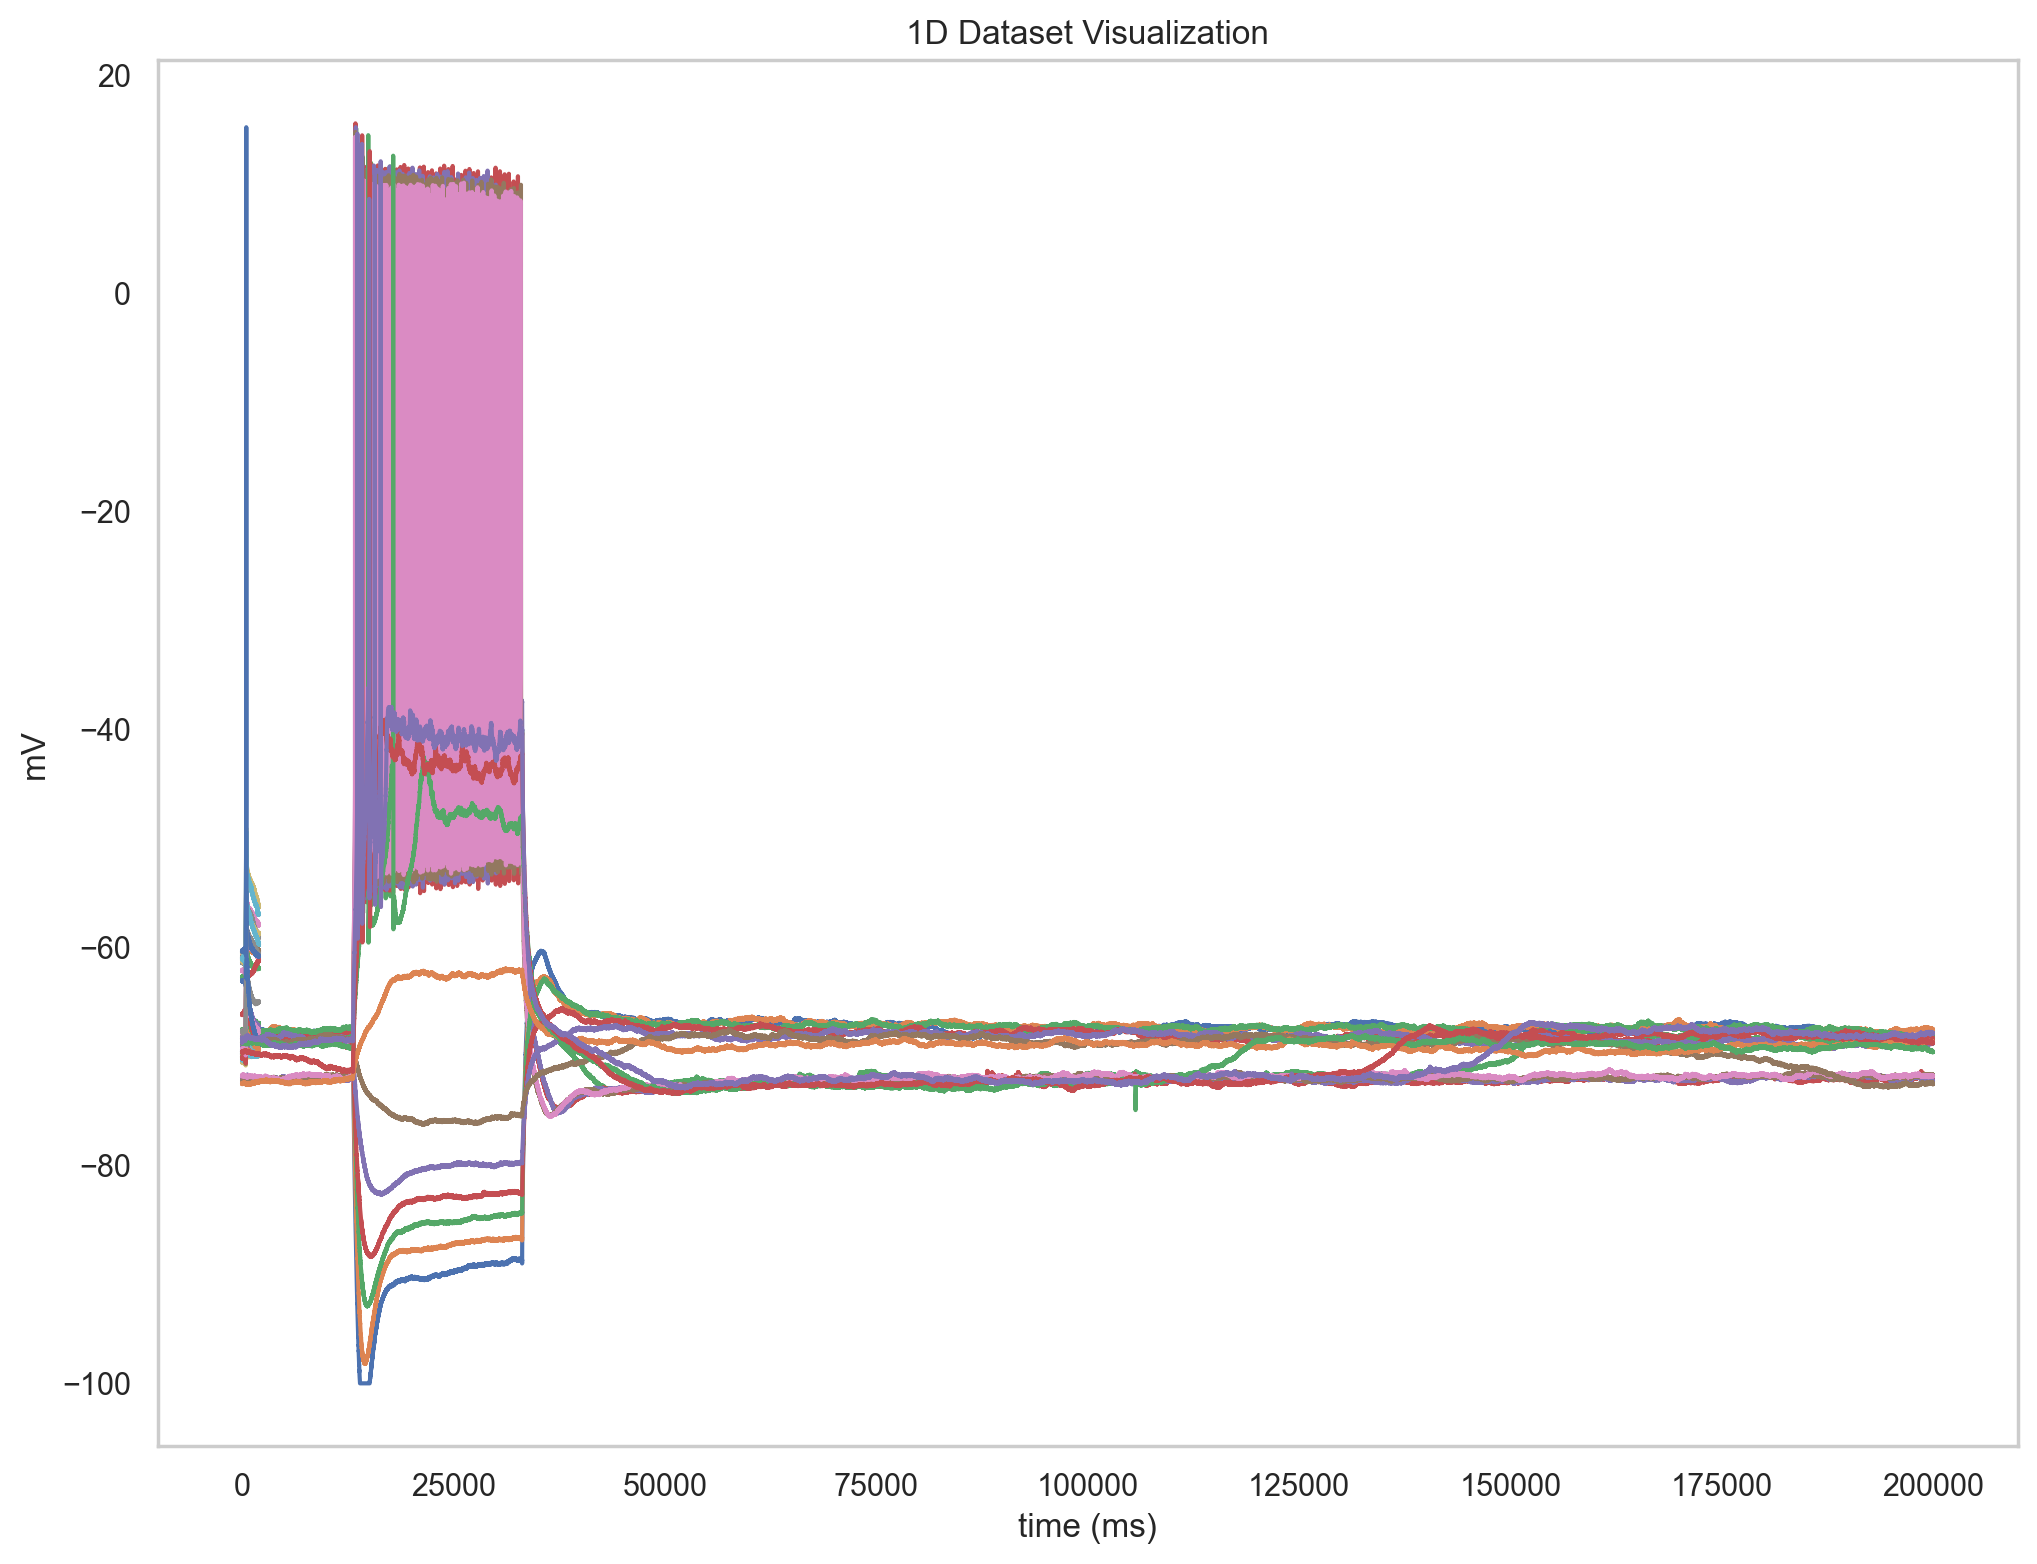

[array([-67.68493804, -67.71545562, -67.7093521 , ..., -68.02368316,
        -68.05420074, -68.03894195]),
 array([-68.05420074, -68.06335601, -68.04809722, ..., -67.55371245,
        -67.55676421, -67.57507475]),
 array([-67.88025054, -67.86193999, -67.83447417, ..., -68.17627106,
        -68.16406402, -68.15185699]),
 array([-68.17932281, -68.1732193 , -68.13354644, ..., -71.95129555,
        -71.92077797, -71.91467446]),
 array([-71.92382973, -71.96350259, -71.93603676, ..., -72.30224771,
        -72.23816079, -72.20764322]),
 array([-72.23205728, -72.23510904, -72.20459146, ..., -71.74072426,
        -71.7163102 , -71.75598305]),
 array([-71.70410317, -71.72851723, -71.72851723, ..., -71.79870766,
        -71.81091469, -71.76819008]),
 array([-69.77539218, -69.75708164, -69.70825351, ..., -69.59839023,
        -69.54345859, -69.59228671]),
 array([-70.03173985, -70.07446446, -70.09887852, ..., -69.91577305,
        -69.95849766, -69.90966953]),
 array([-69.72046054, -69.82422031, -

In [5]:
# Function to visualize sweep patch data
# no metadata, just the time series data
def extract_data(file_path, plot_data = True):
    # Open the HDF5 file
    with h5py.File(file_path, 'r') as f:
        # Initialize an empty list to store data arrays
        data = []

        # Iterate through keys in the 'acquisition' group
        for sweep_key in f['acquisition'].keys():
            dataset = f['acquisition'][sweep_key]['data'] 
            # Convert the dataset data into a NumPy array and append to the list
            data.append(np.array(dataset))

        # Plot the data
        if(plot_data):
            if all(d.ndim == 1 for d in data):
                for d in data:
                    plt.plot(d)
                plt.xlabel('time (ms)')
                plt.ylabel('mV')
                plt.title('1D Dataset Visualization')
                plt.show()
            elif all(d.ndim == 2 for d in data):
                for d in data:
                    plt.imshow(d, cmap='viridis')
                    plt.colorbar()
                    plt.xlabel('X-axis')
                    plt.ylabel('Y-axis')
                    plt.title('2D Dataset Visualization')
                    plt.show()
            else:
                print("Cannot visualize data with more than 2 dimensions.")



        return data


extract_data(file1)

In [6]:
data = extract_data(file1, plot_data = False)
spike_dir = {}
i = 0
#threshold in mVs
with h5py.File(file1, 'r') as f:
    for sweep_key in f['acquisition'].keys():
        print(sweep_key)
        sweep_key_obj = Spike(thresh_amp=0, window_length=(5., 5.), smooth_frac=.01)
        sweep_key_obj.fit(data[i], 20000, n_jobs=-1, progress=tqdm)
        if sweep_key_obj.n_spikes != None:
             spike_dir[sweep_key] = sweep_key_obj
        
        i += 1

Sweep_0
Sweep_1
Sweep_10


C:\Users\david\spikeparam\spikeparam\patch\fit\fit.py:228: UserWarning: No spikes detected.
  warnings.warn('No spikes detected.')
Spike: 100%|█████████████████████████████████████████████████████████████████████████████| 9/9 [00:03<00:00,  2.26it/s]


Sweep_11


Spike: 100%|███████████████████████████████████████████████████████████████████████████| 42/42 [00:04<00:00,  8.98it/s]


Sweep_12


...

Spike: 100%|█████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.33s/it]


Sweep_8


Spike: 100%|█████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.34s/it]


Sweep_9


Spike: 100%|█████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  1.76it/s]


In [7]:
for i in spike_dir:
    print(i)
    print(spike_dir[i])

Sweep_10
Sweep_11
Sweep_12
Sweep_13
Sweep_14
Sweep_54
Sweep_7
Sweep_8
Sweep_9


In [8]:
spike_dir['Sweep_13'].df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
0,2.772189,0.50,-46.041871,14.828492,0.50,5.632019,9.489897,-55.306469,9.65,0.984536,0.351605
1,2.515612,0.50,-43.316651,12.844849,0.55,5.067444,7.469348,-52.921378,10.65,0.994416,0.588534
2,2.544799,0.55,-41.412354,12.292481,0.55,4.263306,7.548379,-52.117200,11.35,0.983035,0.592489
3,2.214429,0.60,-40.573121,11.392212,0.60,3.712463,7.031884,-51.790515,12.85,0.966185,0.632913
4,2.144307,0.60,-39.523316,11.538697,0.55,3.878784,6.710366,-51.738577,13.30,0.986463,0.688141
5,2.552692,0.60,-38.699342,11.239624,0.55,3.414917,6.885040,-51.433379,13.95,0.998462,0.677294
6,2.064595,0.60,-39.120484,10.678101,0.60,3.392029,6.074575,-51.636247,14.65,0.990839,0.776854
7,2.309378,0.65,-39.172364,11.029053,0.60,3.359985,6.543454,-51.628136,15.70,0.993537,0.736869
8,2.147979,0.60,-38.046265,10.678101,0.60,3.224182,6.262882,-51.058364,14.10,0.991177,0.751655
9,2.176615,0.60,-38.366700,10.995484,0.60,3.422546,6.375313,-51.108616,15.00,0.981906,0.748402


## PLOTS

Sweep_10 <spikeparam.patch.fit.fit.Spike object at 0x000001F55798D1C0>
Sweep_11 <spikeparam.patch.fit.fit.Spike object at 0x000001F519CB5880>
Sweep_12 <spikeparam.patch.fit.fit.Spike object at 0x000001F5195D7C20>
Sweep_13 <spikeparam.patch.fit.fit.Spike object at 0x000001F519A4F920>
Sweep_14 <spikeparam.patch.fit.fit.Spike object at 0x000001F5199BFBF0>
Sweep_54 <spikeparam.patch.fit.fit.Spike object at 0x000001F519CDB620>
Sweep_7 <spikeparam.patch.fit.fit.Spike object at 0x000001F5579ADA30>
Sweep_8 <spikeparam.patch.fit.fit.Spike object at 0x000001F519199CD0>
Sweep_9 <spikeparam.patch.fit.fit.Spike object at 0x000001F519D56A50>


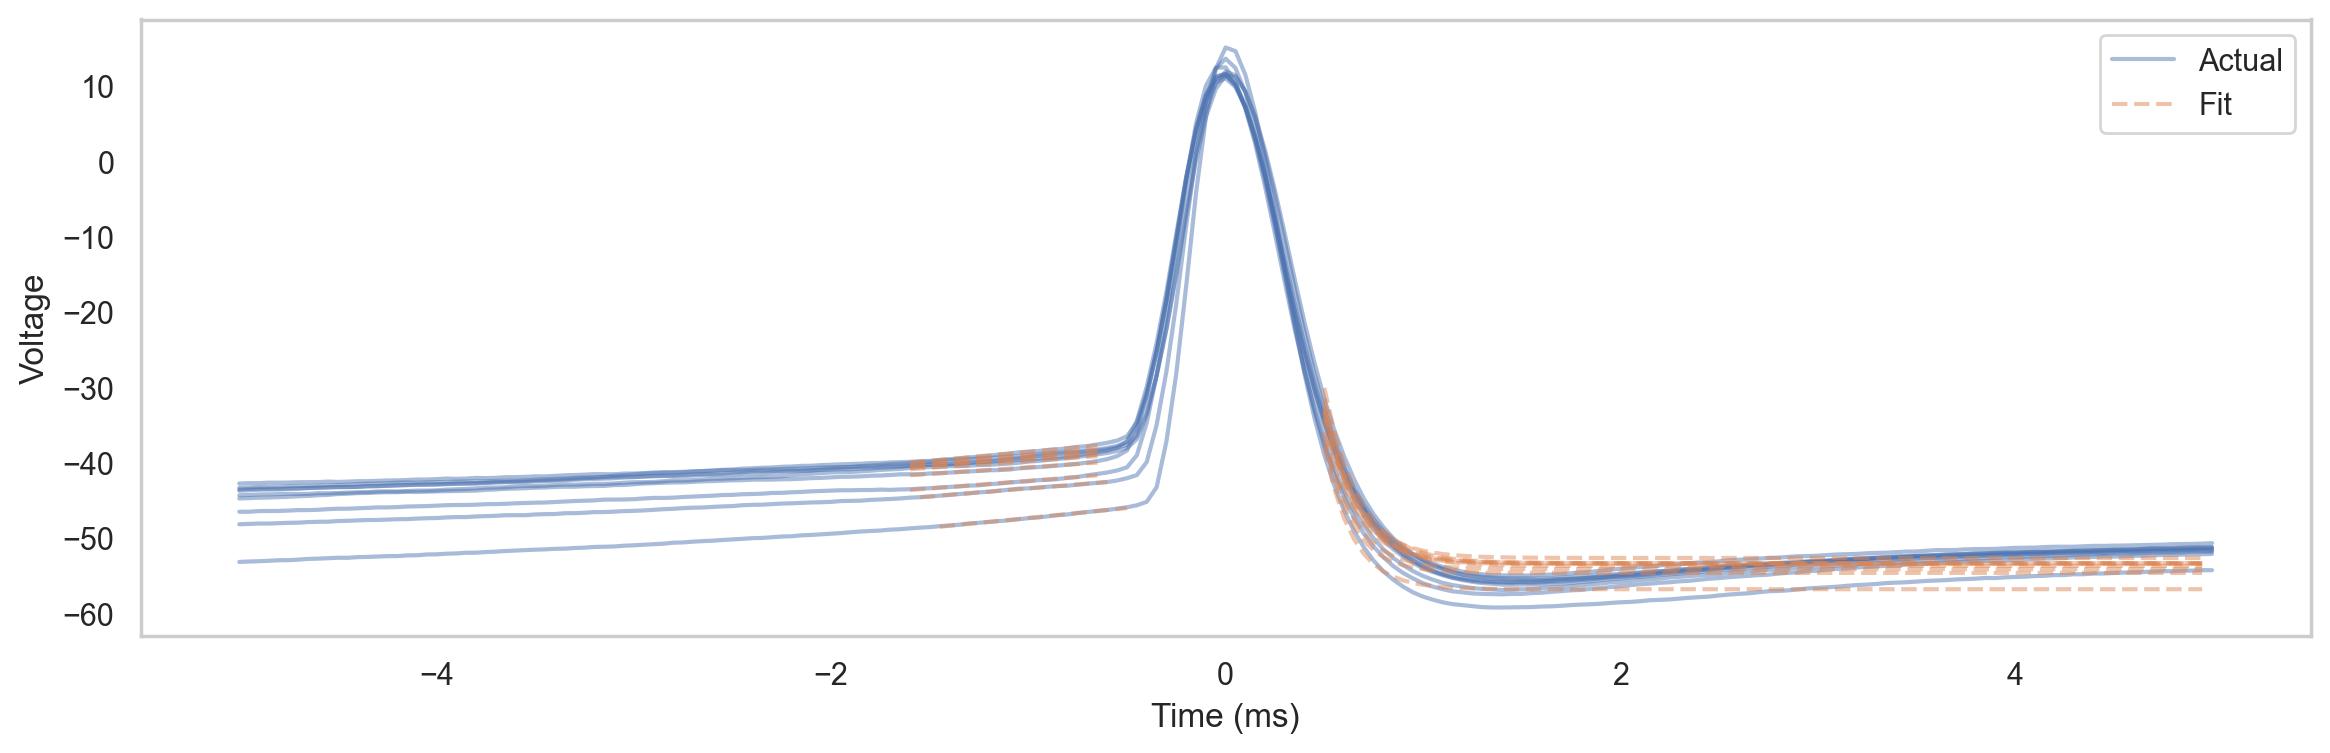

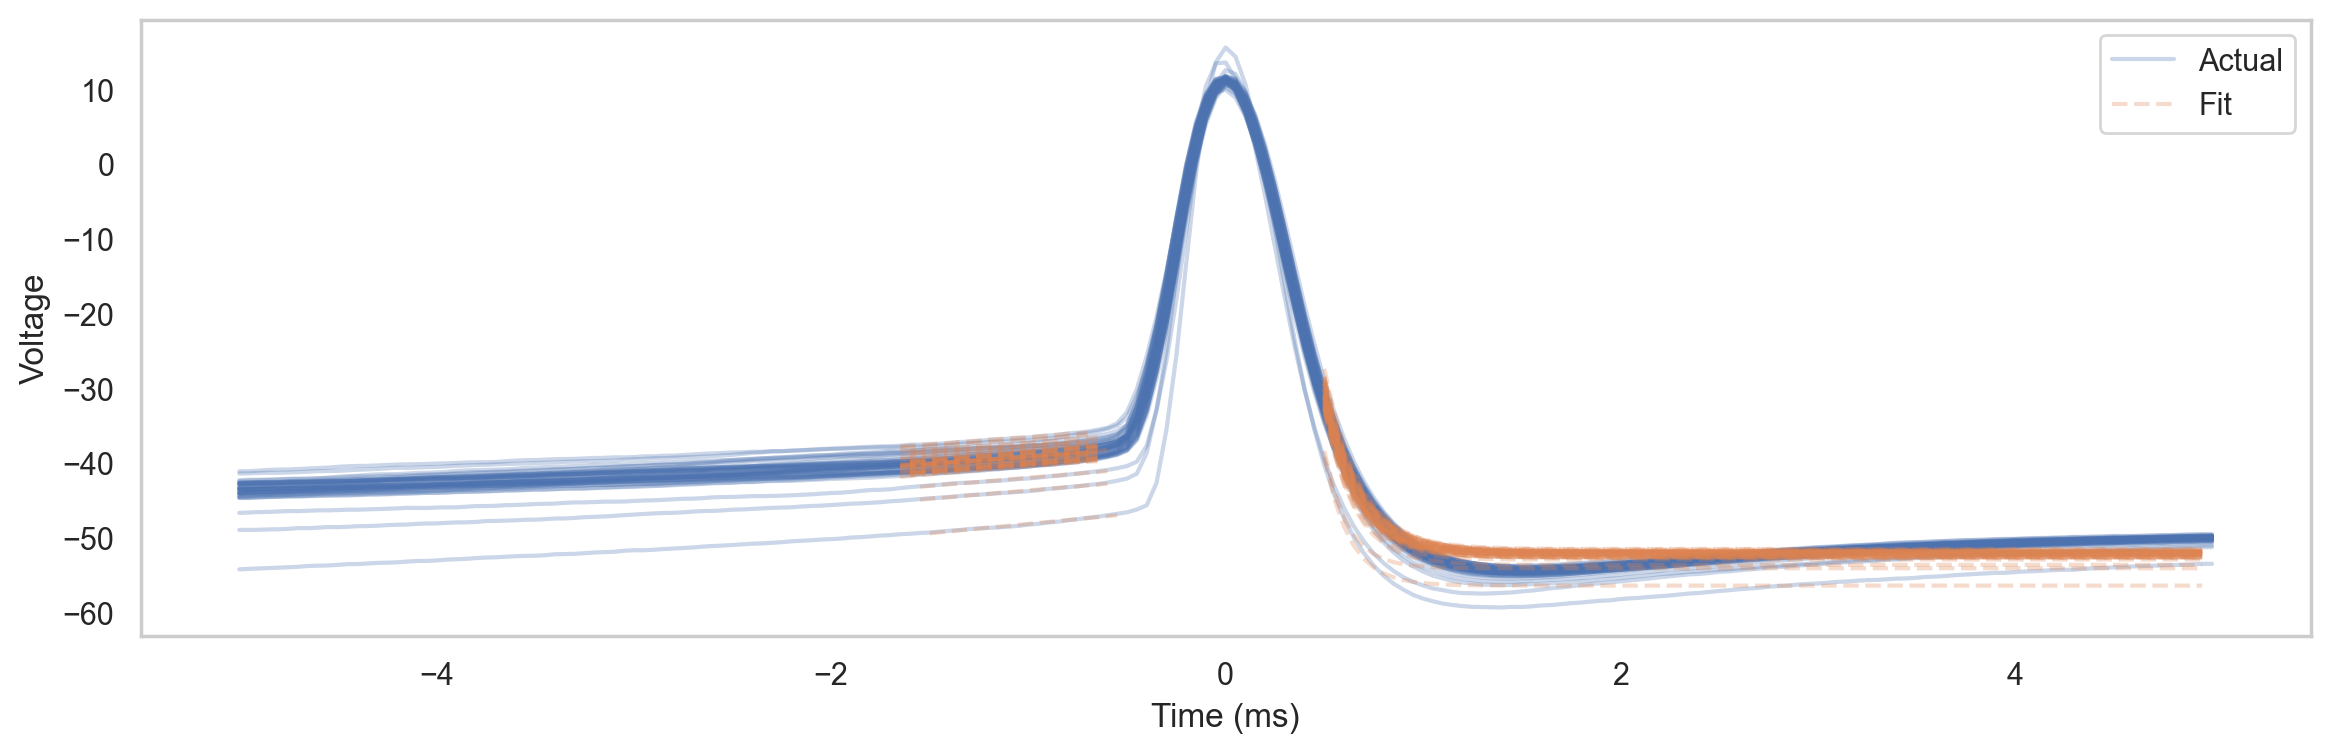

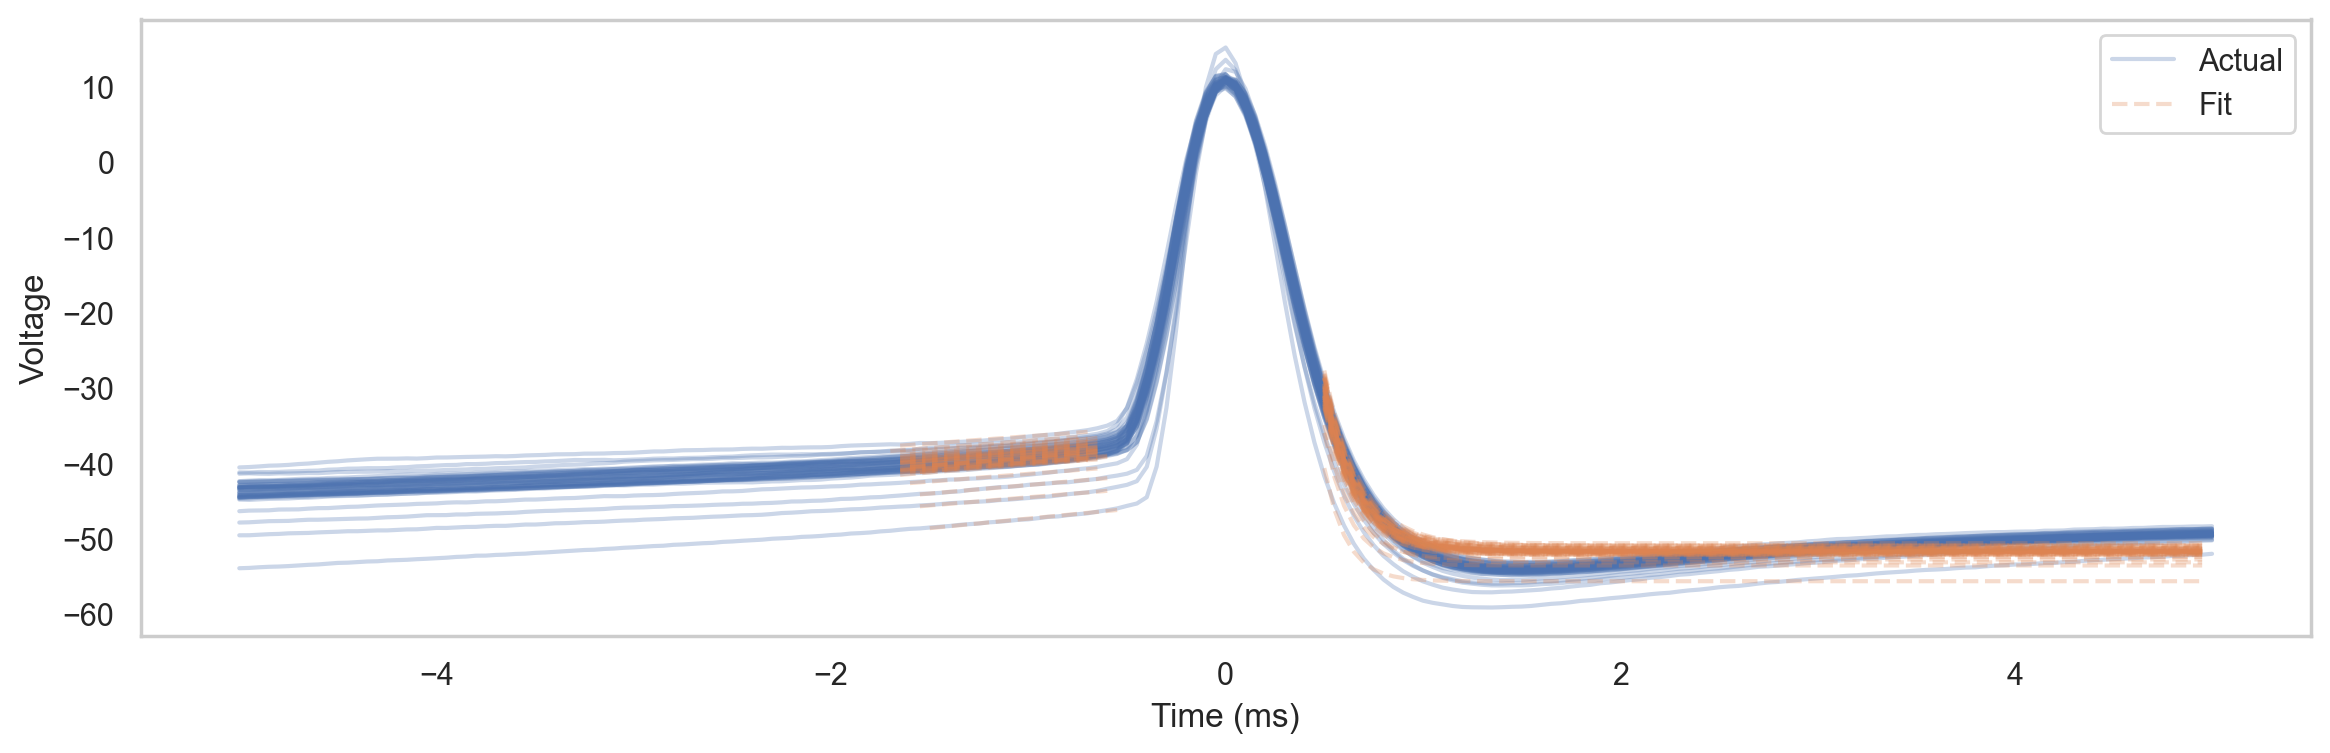

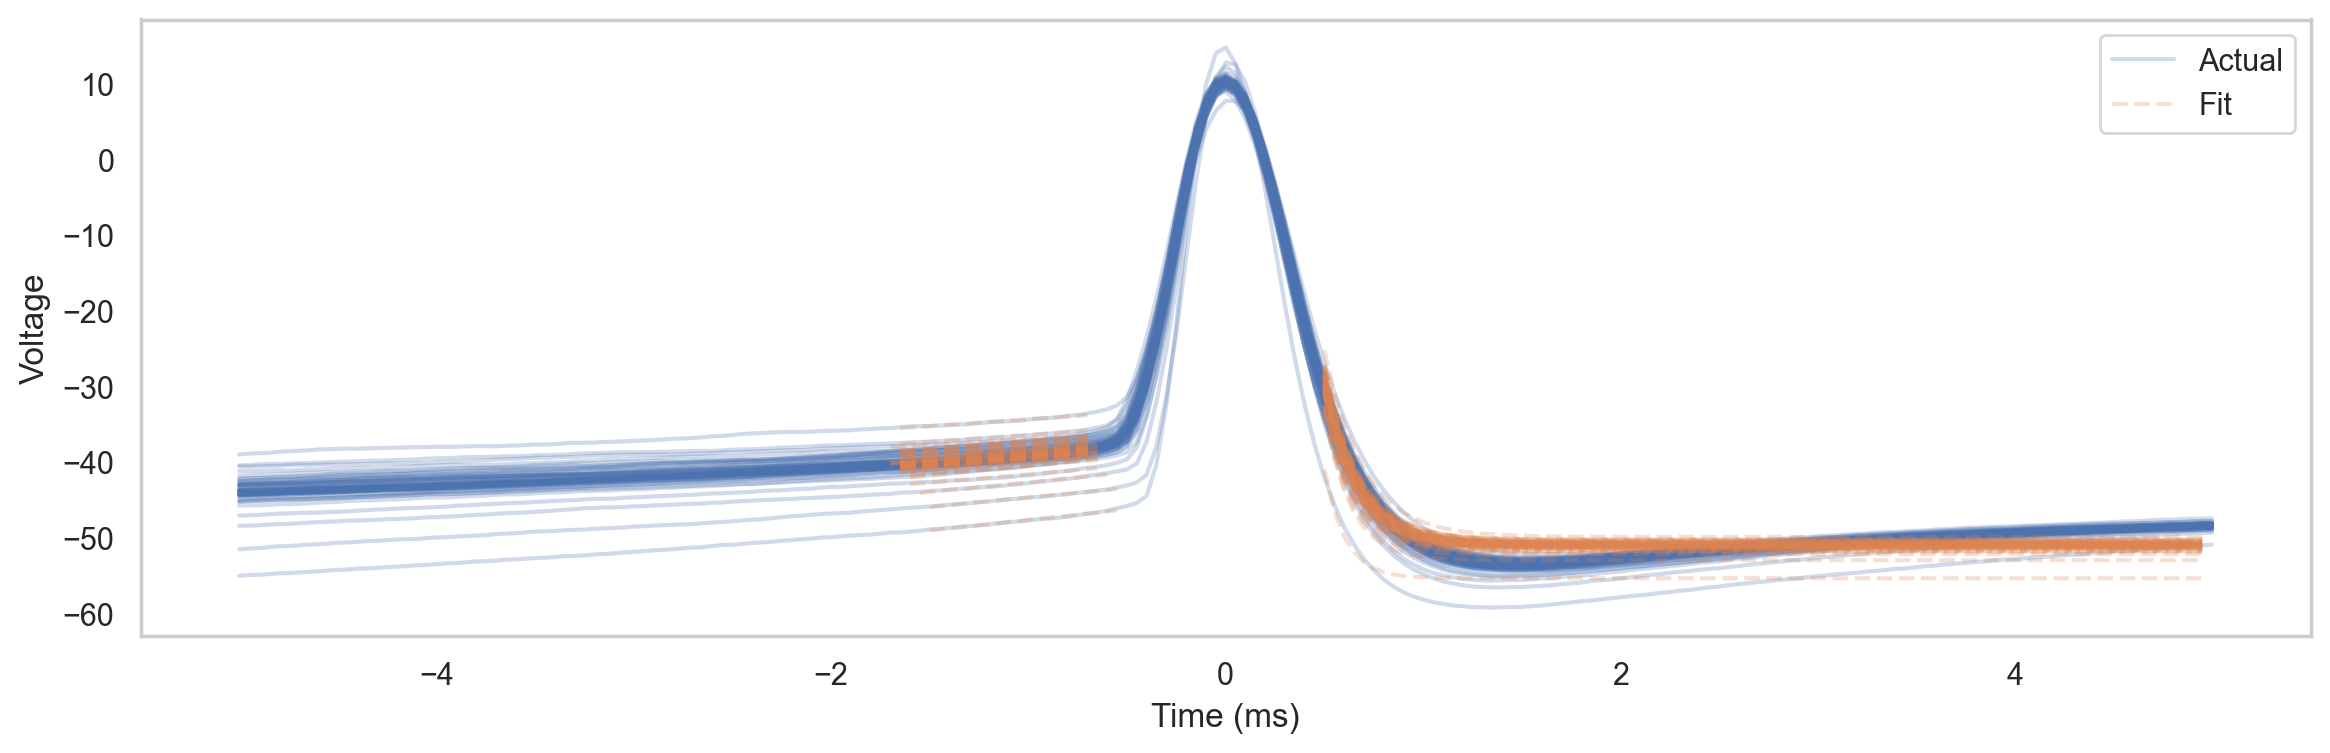

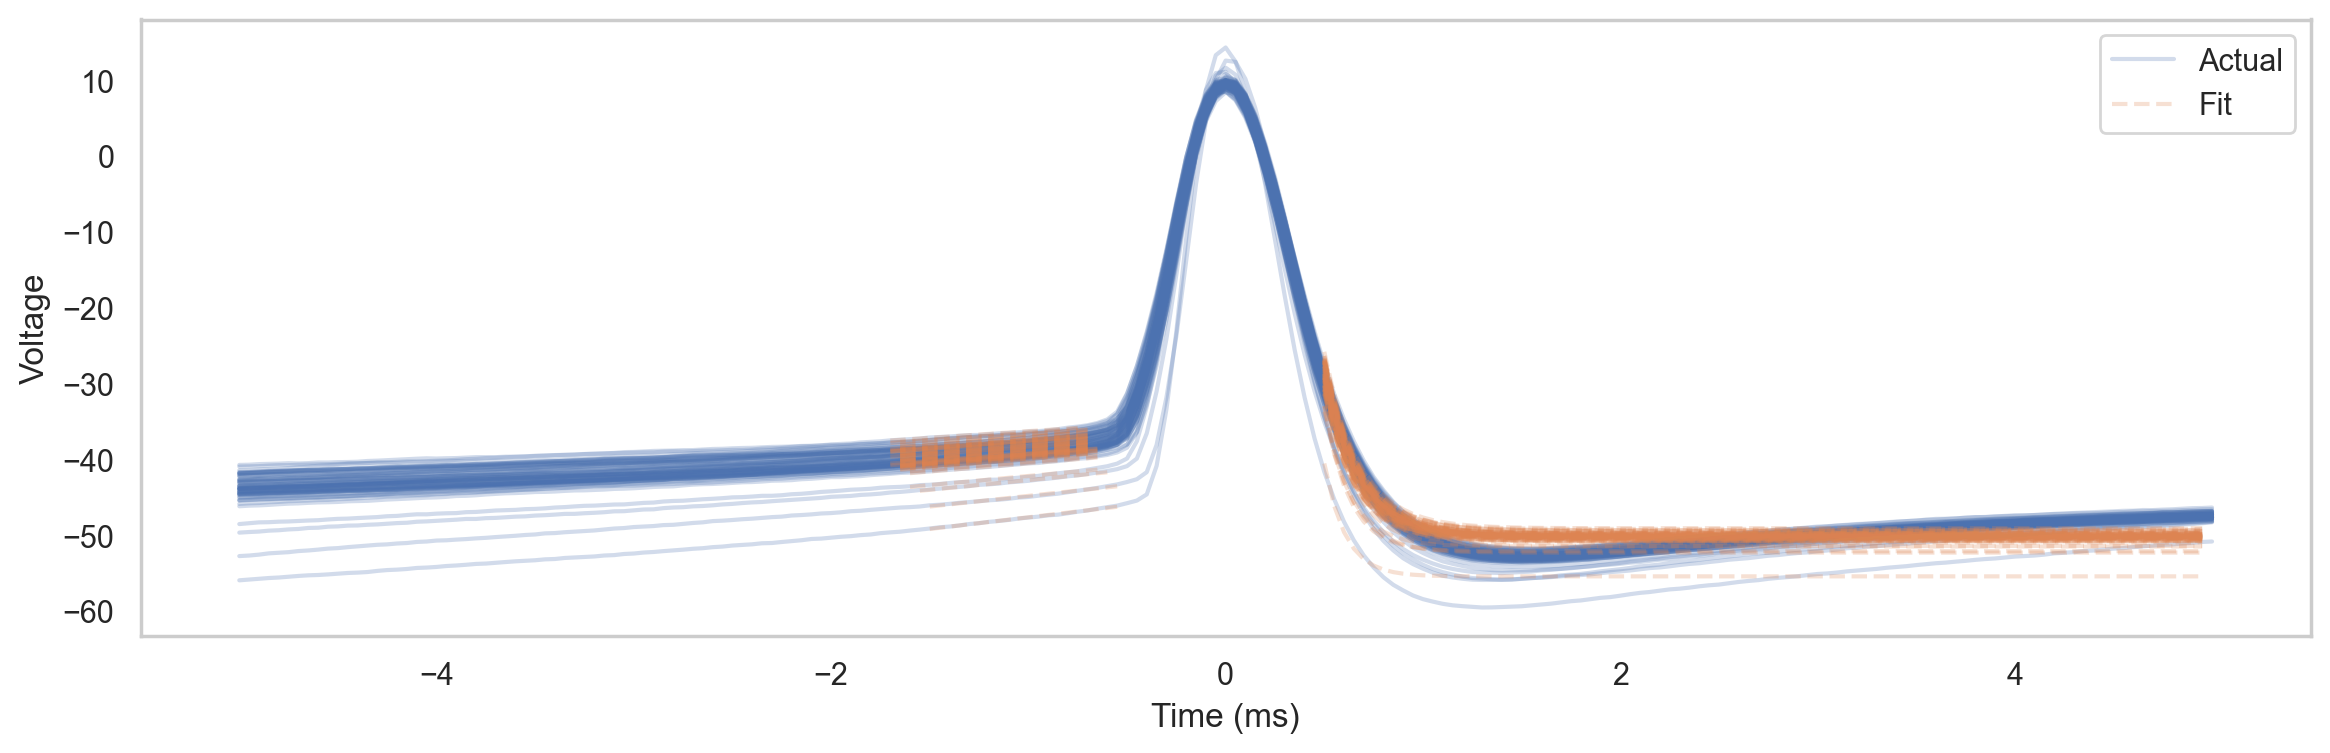

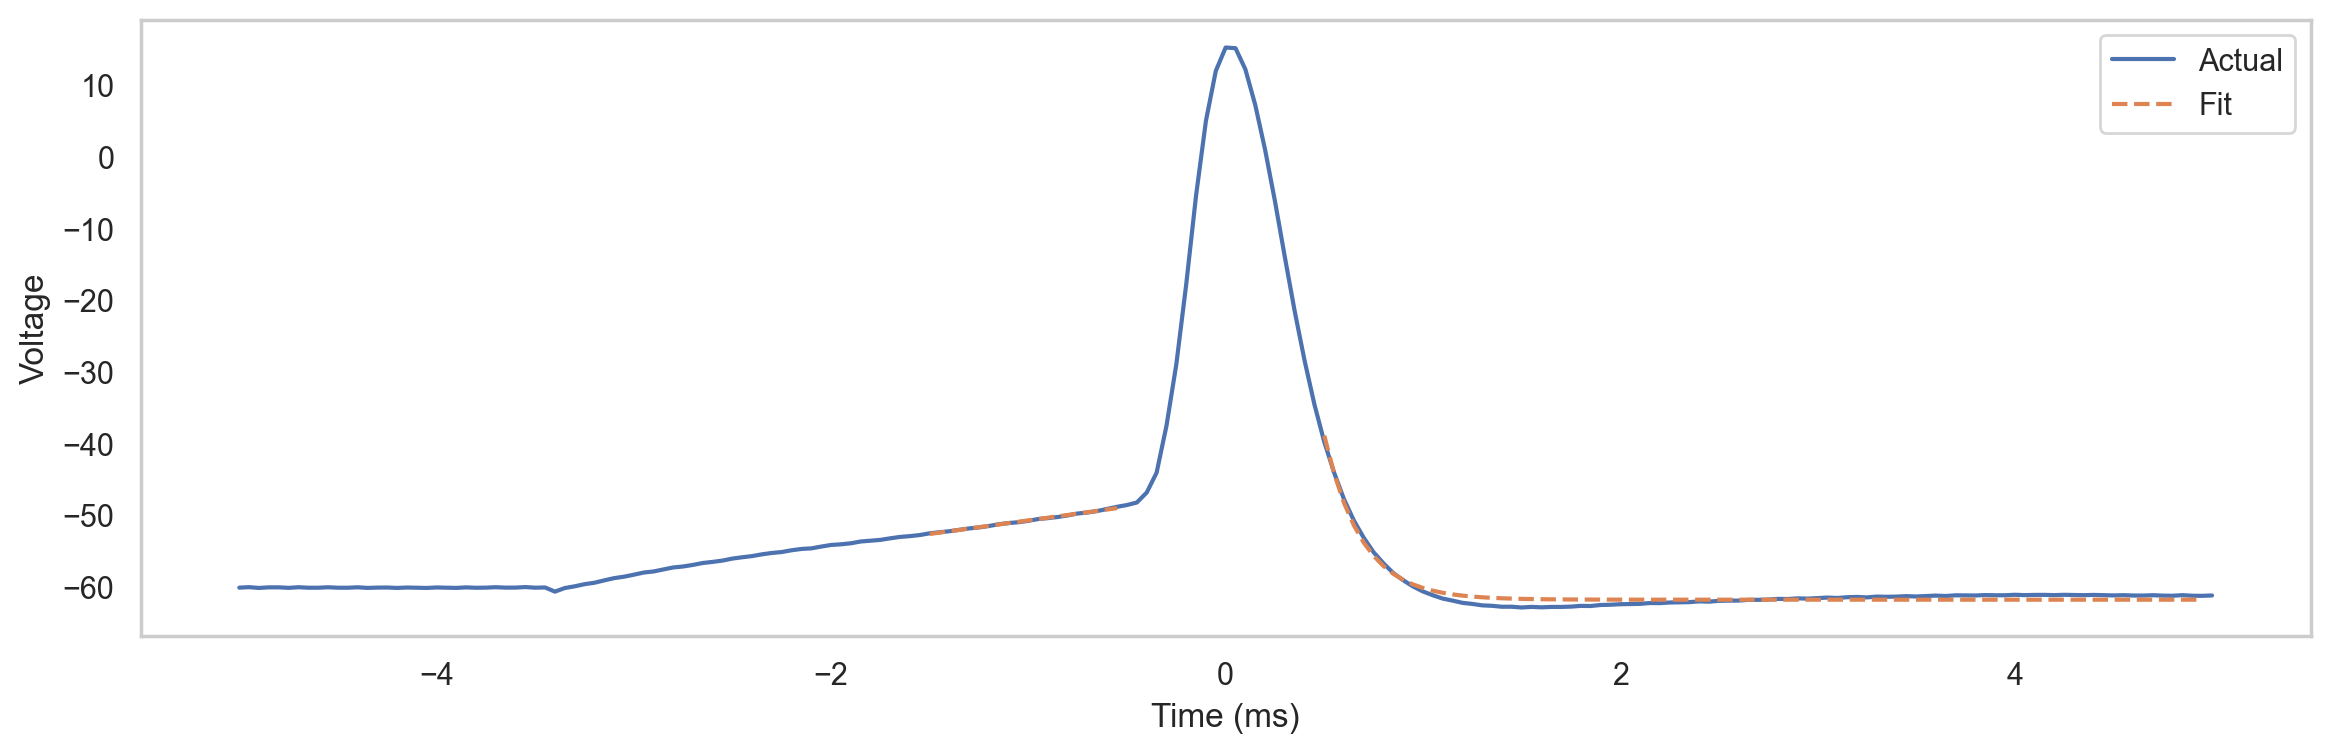

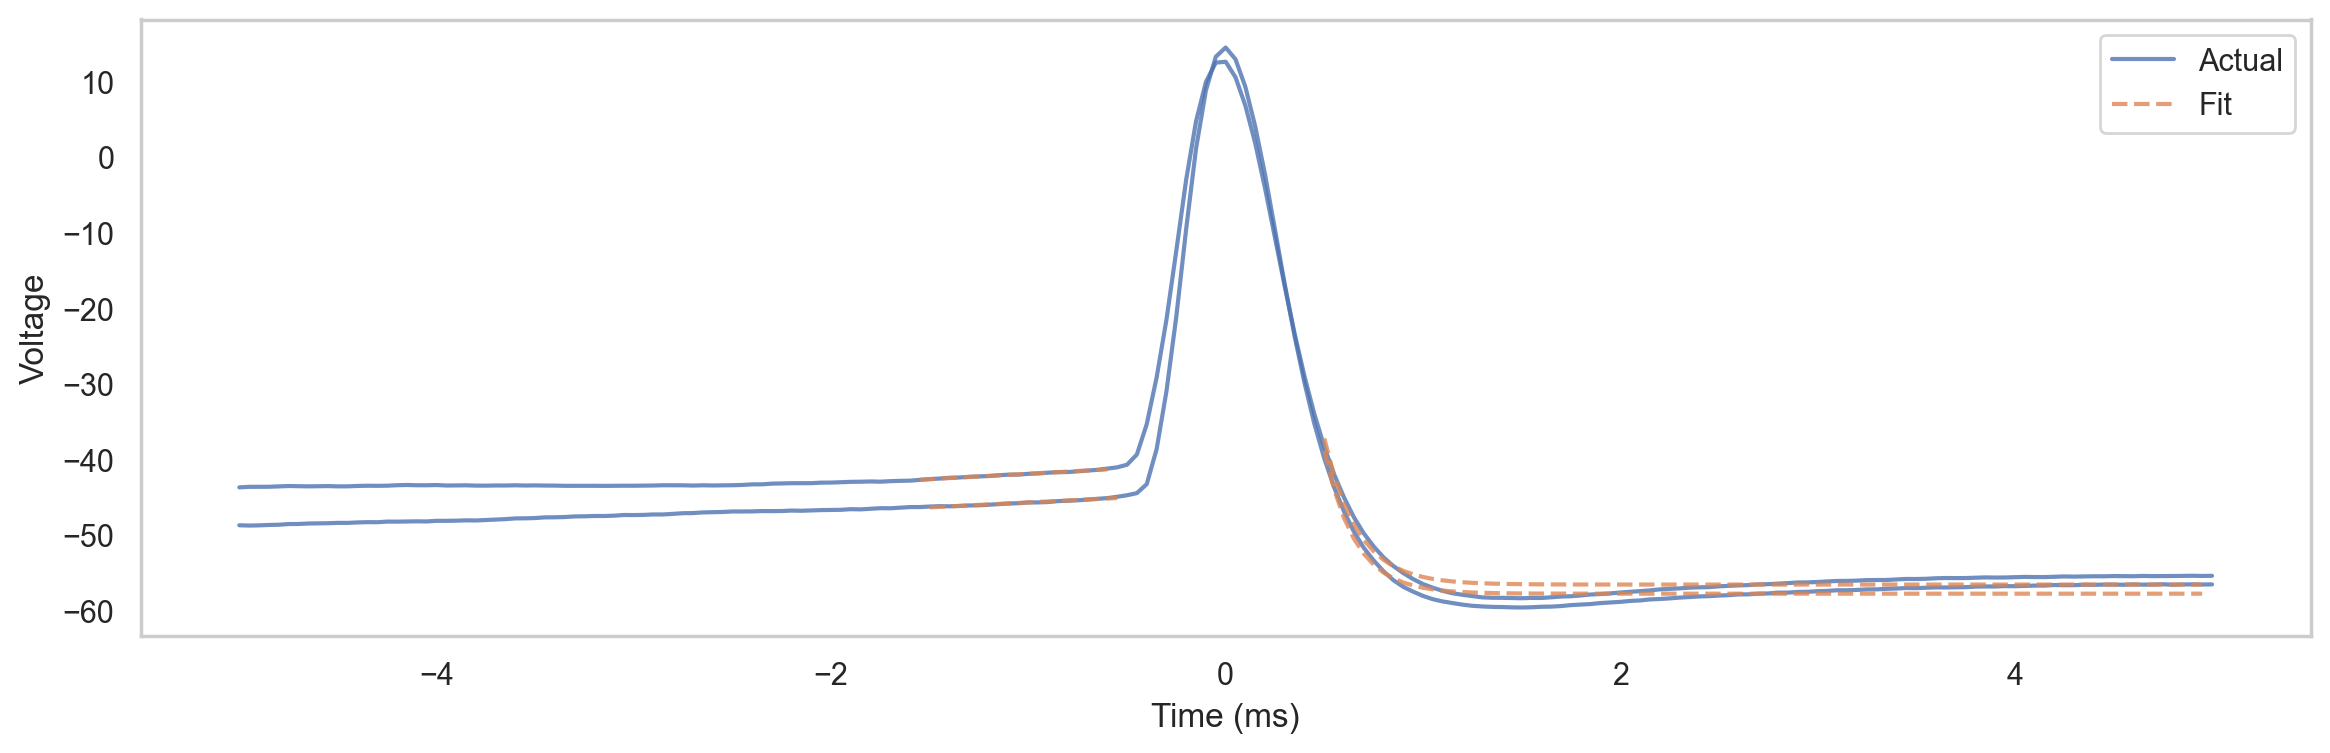

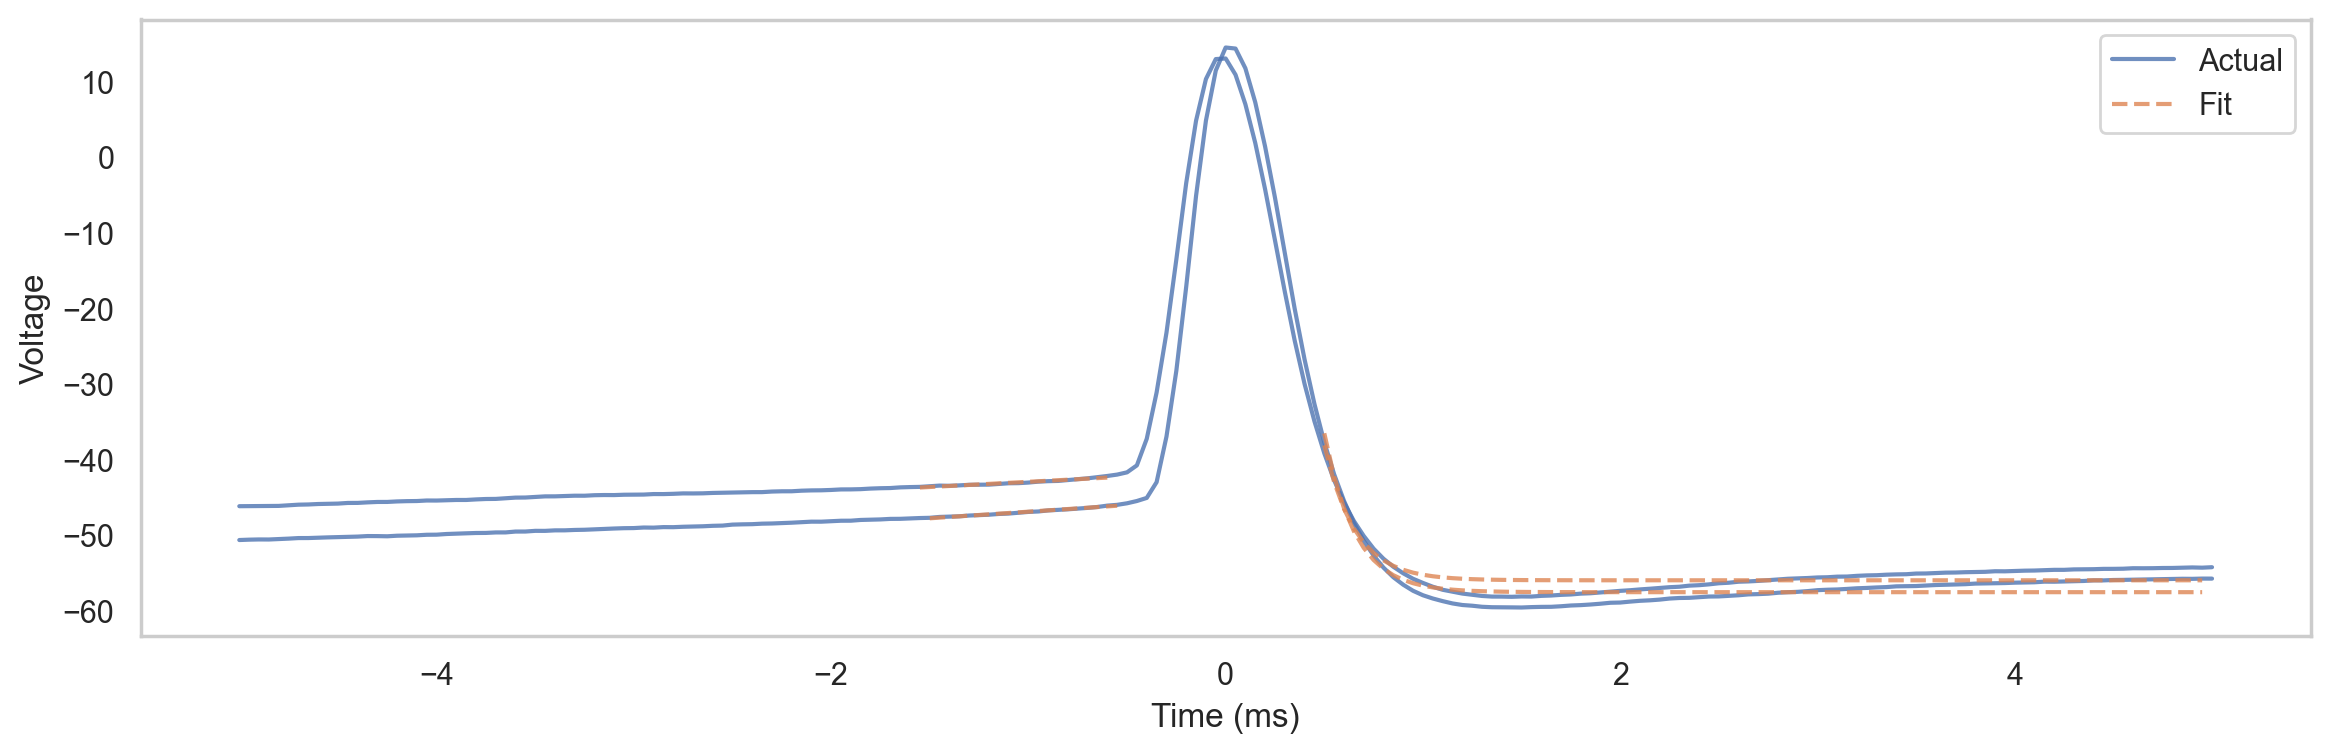

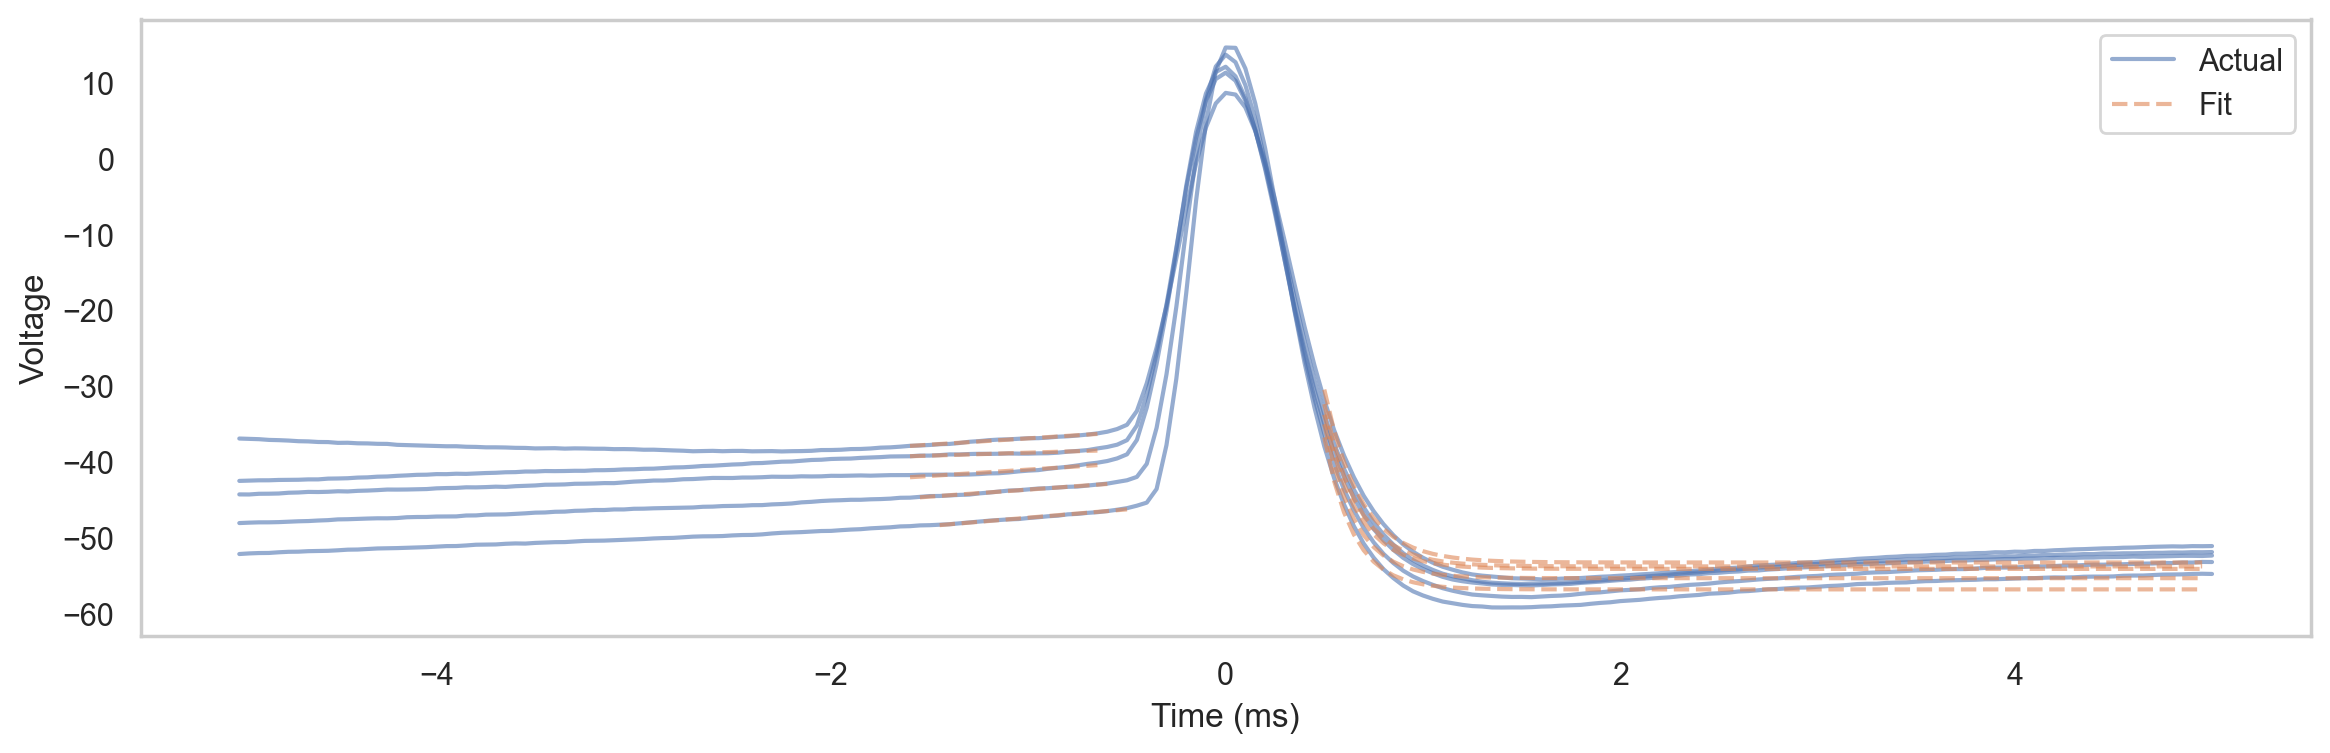

In [9]:
for key in spike_dir:
    value = spike_dir[key]
    print(key, value)
    value.plot()
    

In [10]:
test_df = spike_dir['Sweep_13'].df_features

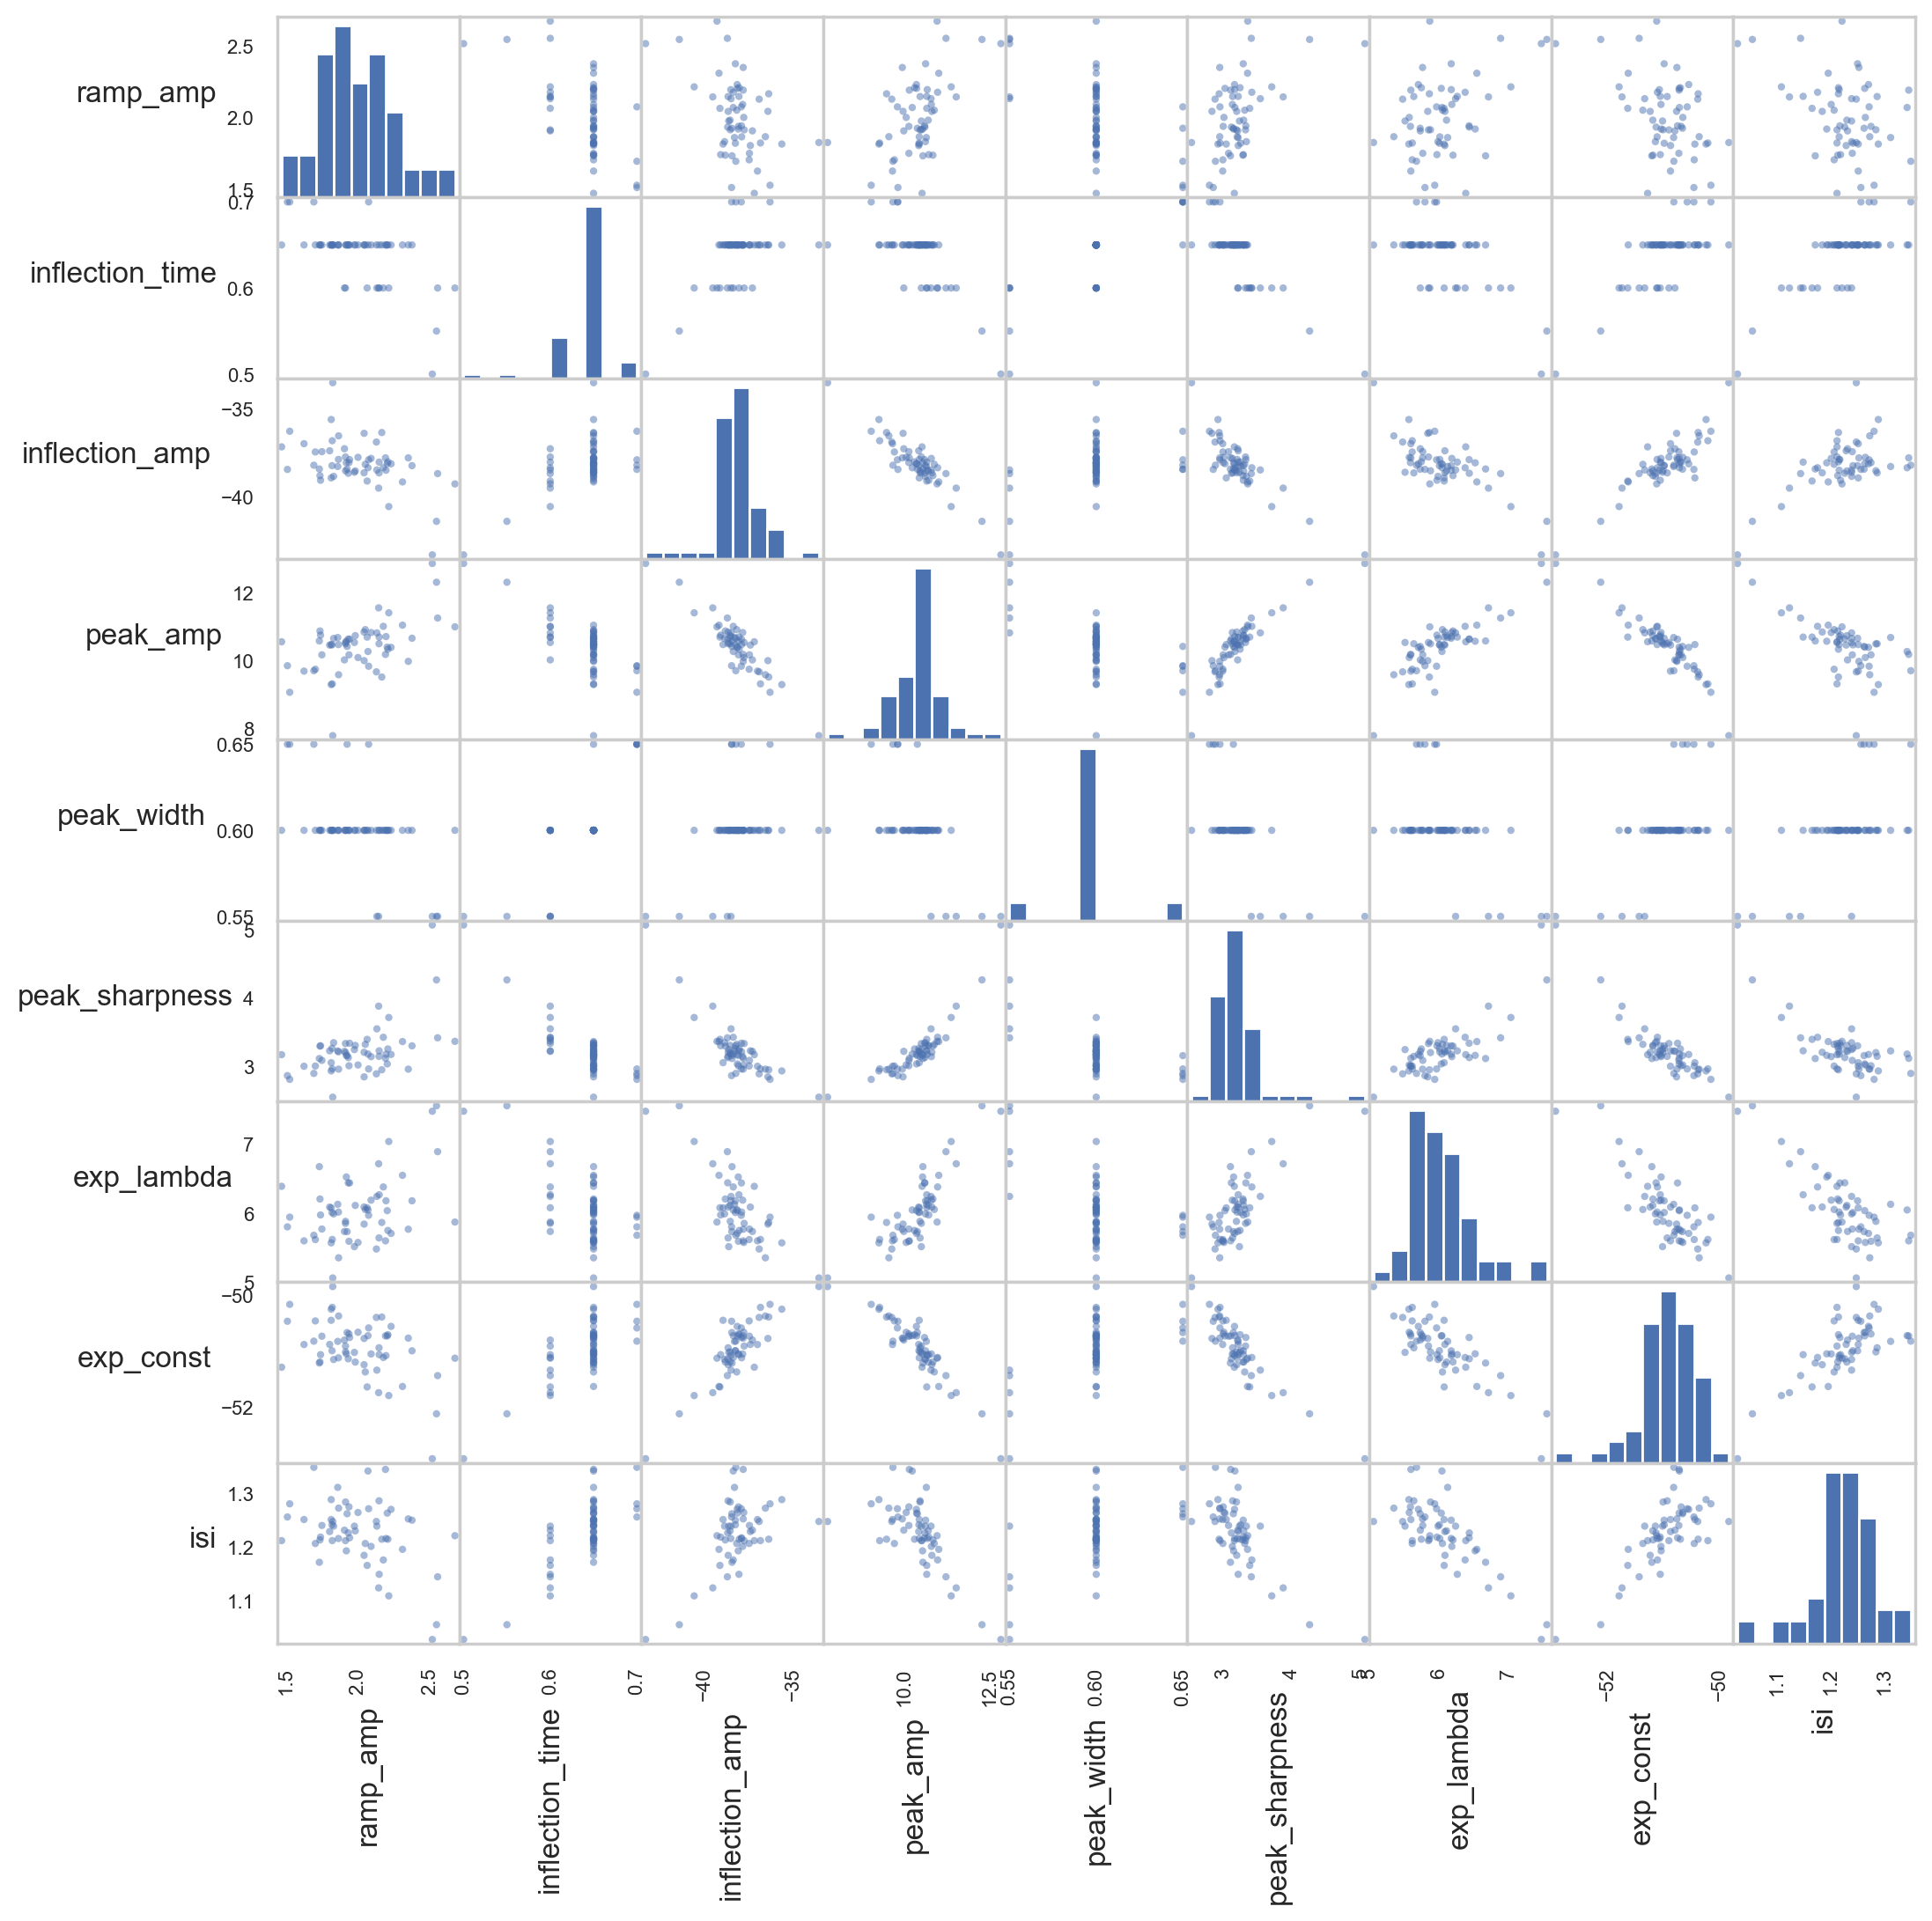

In [11]:
# Ensure inflection times are between 0 and 2 ms
test_df = test_df.loc[test_df['inflection_time'] > 0.]
test_df = test_df.loc[test_df['inflection_time'] < 2.]
# Remove low r-squares (ramping fits are especially noisy)
test_df = test_df.loc[test_df['r_squared_exp']  >= .5]
test_df = test_df.loc[test_df['r_squared_ramp'] >= .1]
# log10 ISIs
test_df[['isi']] = np.log10(test_df[['isi']])
# drop no-longer-used QC features
test_df = test_df.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
test_df = test_df.replace([np.inf, -np.inf], np.nan)

axes = pd.plotting.scatter_matrix(test_df, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()

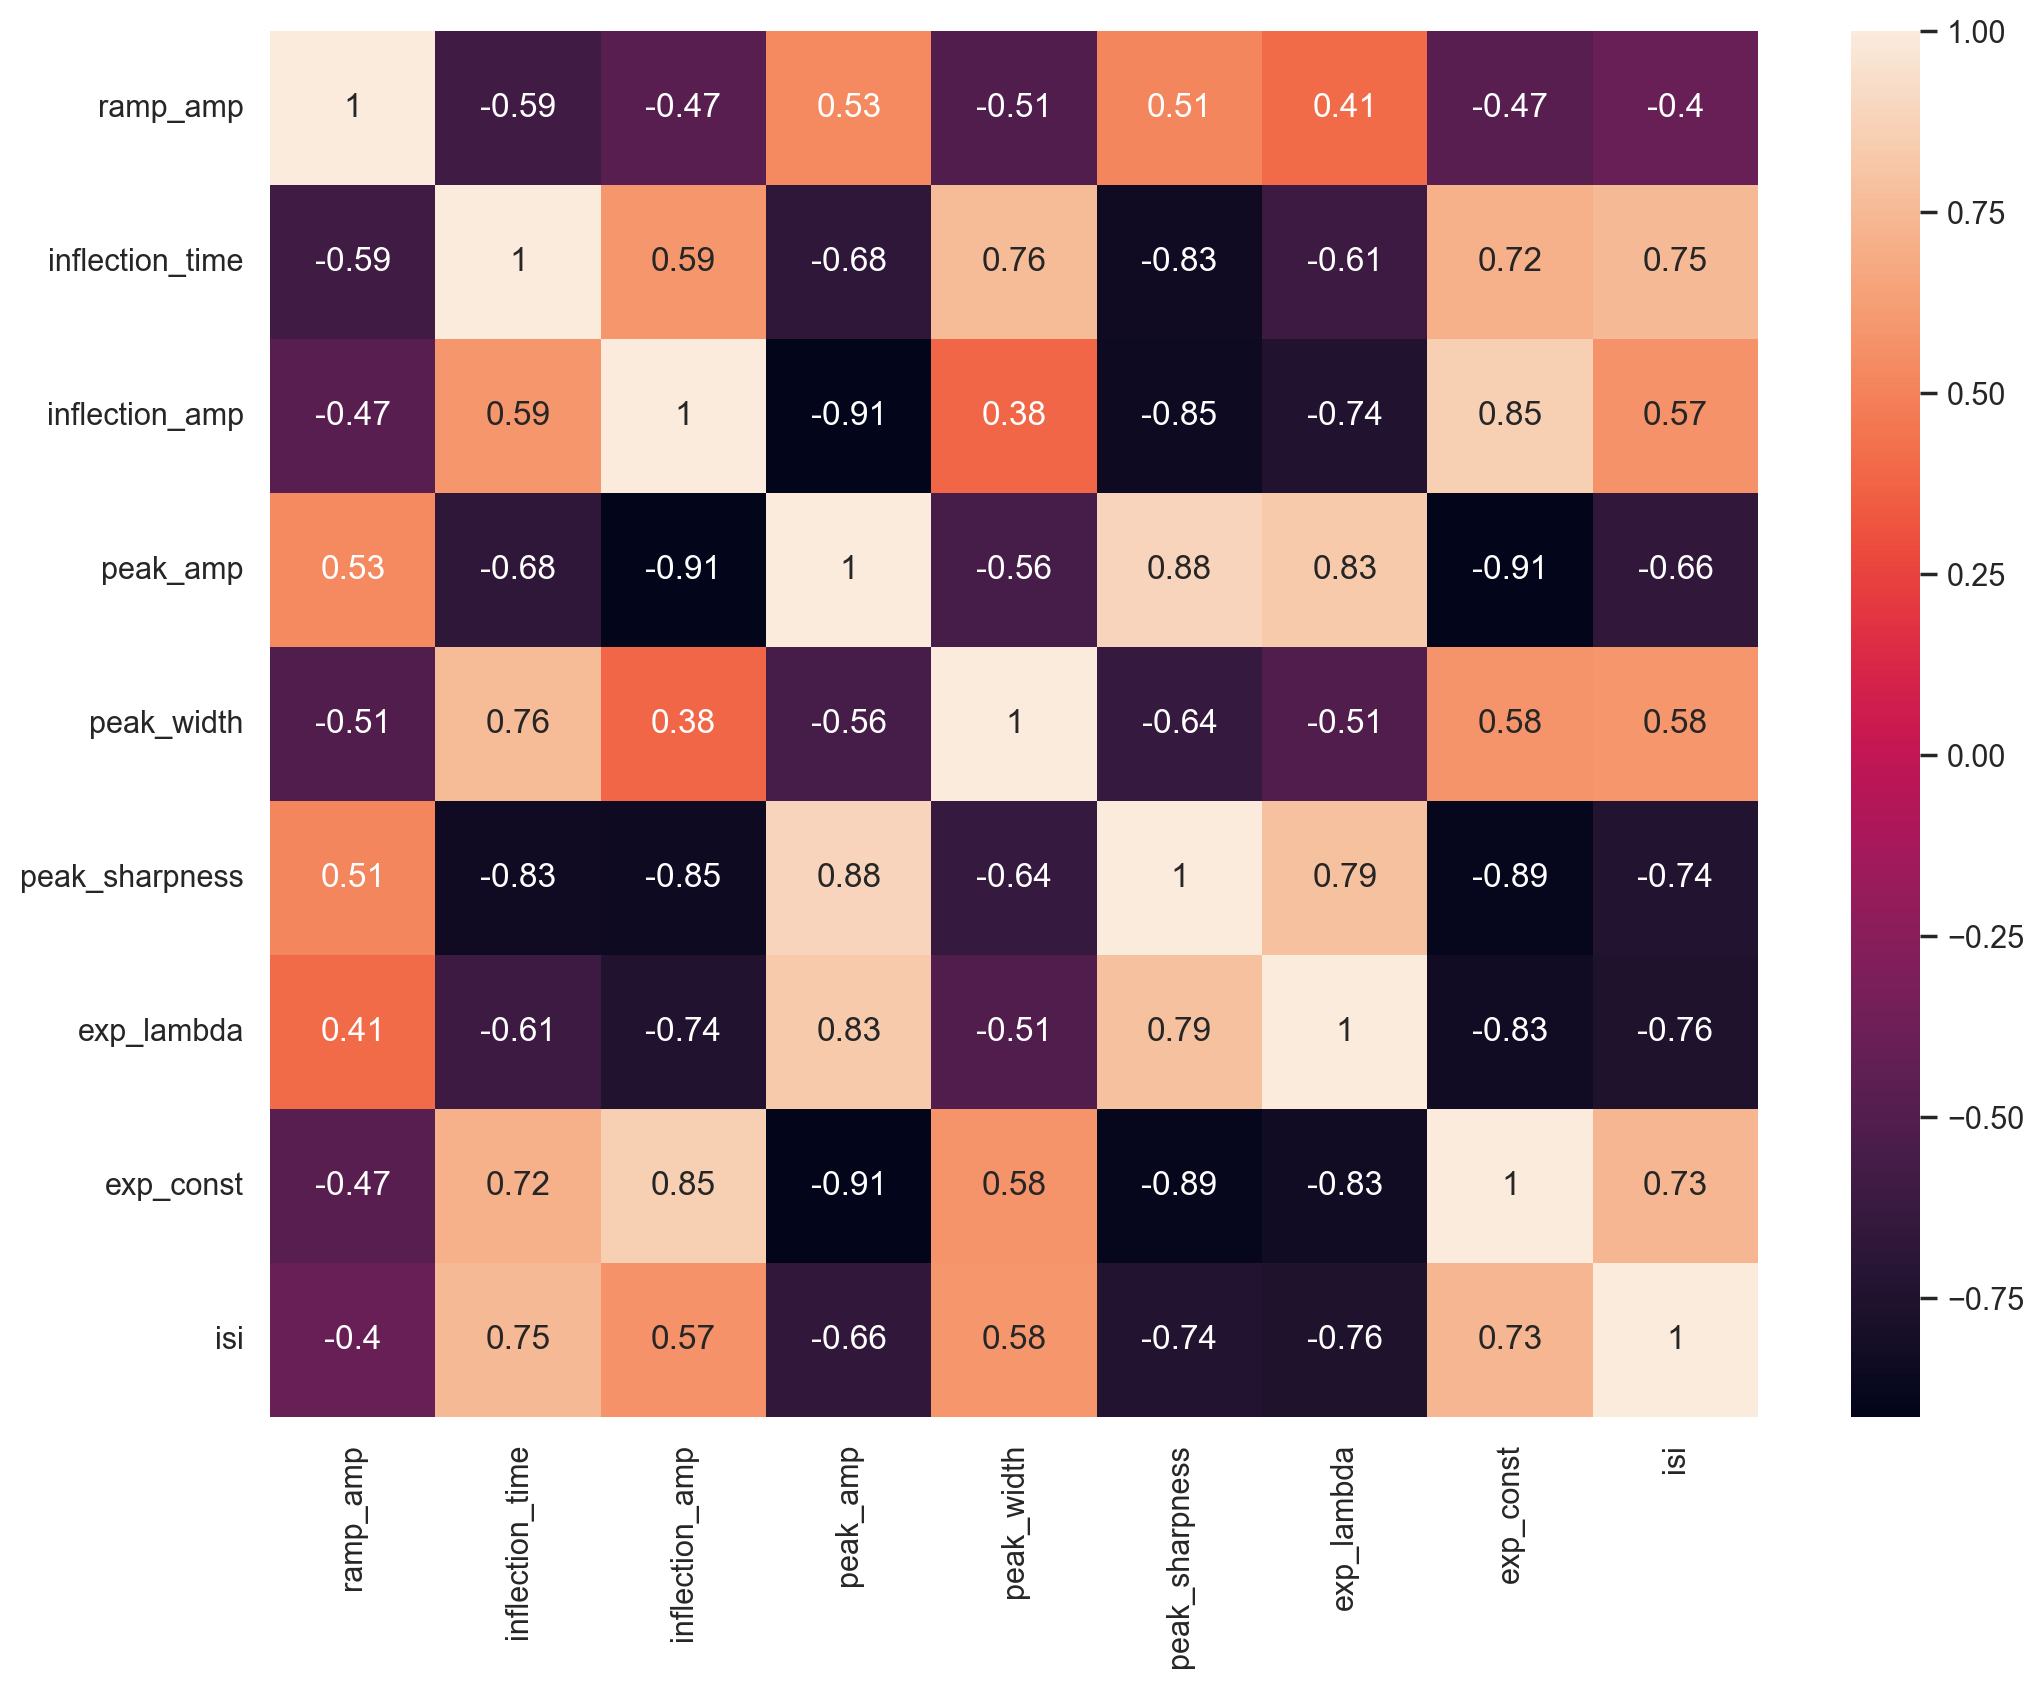

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi
ramp_amp,1.0***,-0.59***,-0.47***,0.53***,-0.51***,0.51***,0.41**,-0.47***,-0.4**
inflection_time,-0.59***,1.0***,0.59***,-0.68***,0.76***,-0.83***,-0.61***,0.72***,0.75***
inflection_amp,-0.47***,0.59***,1.0***,-0.91***,0.38**,-0.85***,-0.74***,0.85***,0.57***
peak_amp,0.53***,-0.68***,-0.91***,1.0***,-0.56***,0.88***,0.83***,-0.91***,-0.66***
peak_width,-0.51***,0.76***,0.38**,-0.56***,1.0***,-0.64***,-0.51***,0.58***,0.58***
peak_sharpness,0.51***,-0.83***,-0.85***,0.88***,-0.64***,1.0***,0.79***,-0.89***,-0.74***
exp_lambda,0.41**,-0.61***,-0.74***,0.83***,-0.51***,0.79***,1.0***,-0.83***,-0.76***
exp_const,-0.47***,0.72***,0.85***,-0.91***,0.58***,-0.89***,-0.83***,1.0***,0.73***
isi,-0.4**,0.75***,0.57***,-0.66***,0.58***,-0.74***,-0.76***,0.73***,1.0***


In [12]:
#test_df_correlation = test_df.corr()
# Plot the heatmap and annotation on it
sns.heatmap(test_df.corr(), xticklabels=test_df.corr().columns,
            yticklabels=test_df.corr().columns, annot=True)
plt.show()
rho = test_df.corr()
pval = test_df.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

# MEGA dataframe
adds each sweep

In [13]:
# creating and concatenating data frame with all sweeps
mega_df = pd.DataFrame()
for i in spike_dir:
    print(i)
    df = spike_dir[i].df_features
    df['Sweep_#'] = i
    mega_df = pd.concat([mega_df, df], axis=0)

print(mega_df.head())
print(mega_df.tail())
mega_df.info()

Sweep_10
Sweep_11
Sweep_12
Sweep_13
Sweep_14
Sweep_54
Sweep_7
Sweep_8
Sweep_9
   ramp_amp  inflection_time  inflection_amp   peak_amp  peak_width  \
0  2.612488             0.45      -45.858766  15.164185        0.50   
1  2.116406             0.55      -42.507936  13.681031        0.50   
2  2.044173             0.60      -41.433717  12.530518        0.55   
3  1.850421             0.60      -38.183595  11.666870        0.55   
4  1.832248             0.60      -38.827516  11.984253        0.55   

   peak_sharpness  exp_lambda  exp_const    isi  r_squared_ramp  \
0        6.445313    6.970228 -56.733916  19.45        0.996142   
1        5.018616    7.193608 -54.574427  20.15        0.998421   
2        3.962708    6.693805 -54.071263  24.25        0.984082   
3        3.634644    6.344601 -53.386135  24.55        0.994742   
4        3.929138    5.981717 -53.646425  26.60        0.950116   

   r_squared_exp   Sweep_#  
0       0.739826  Sweep_10  
1       0.688264  Sweep_10  
2    

**Plotting MEGA dataframe**

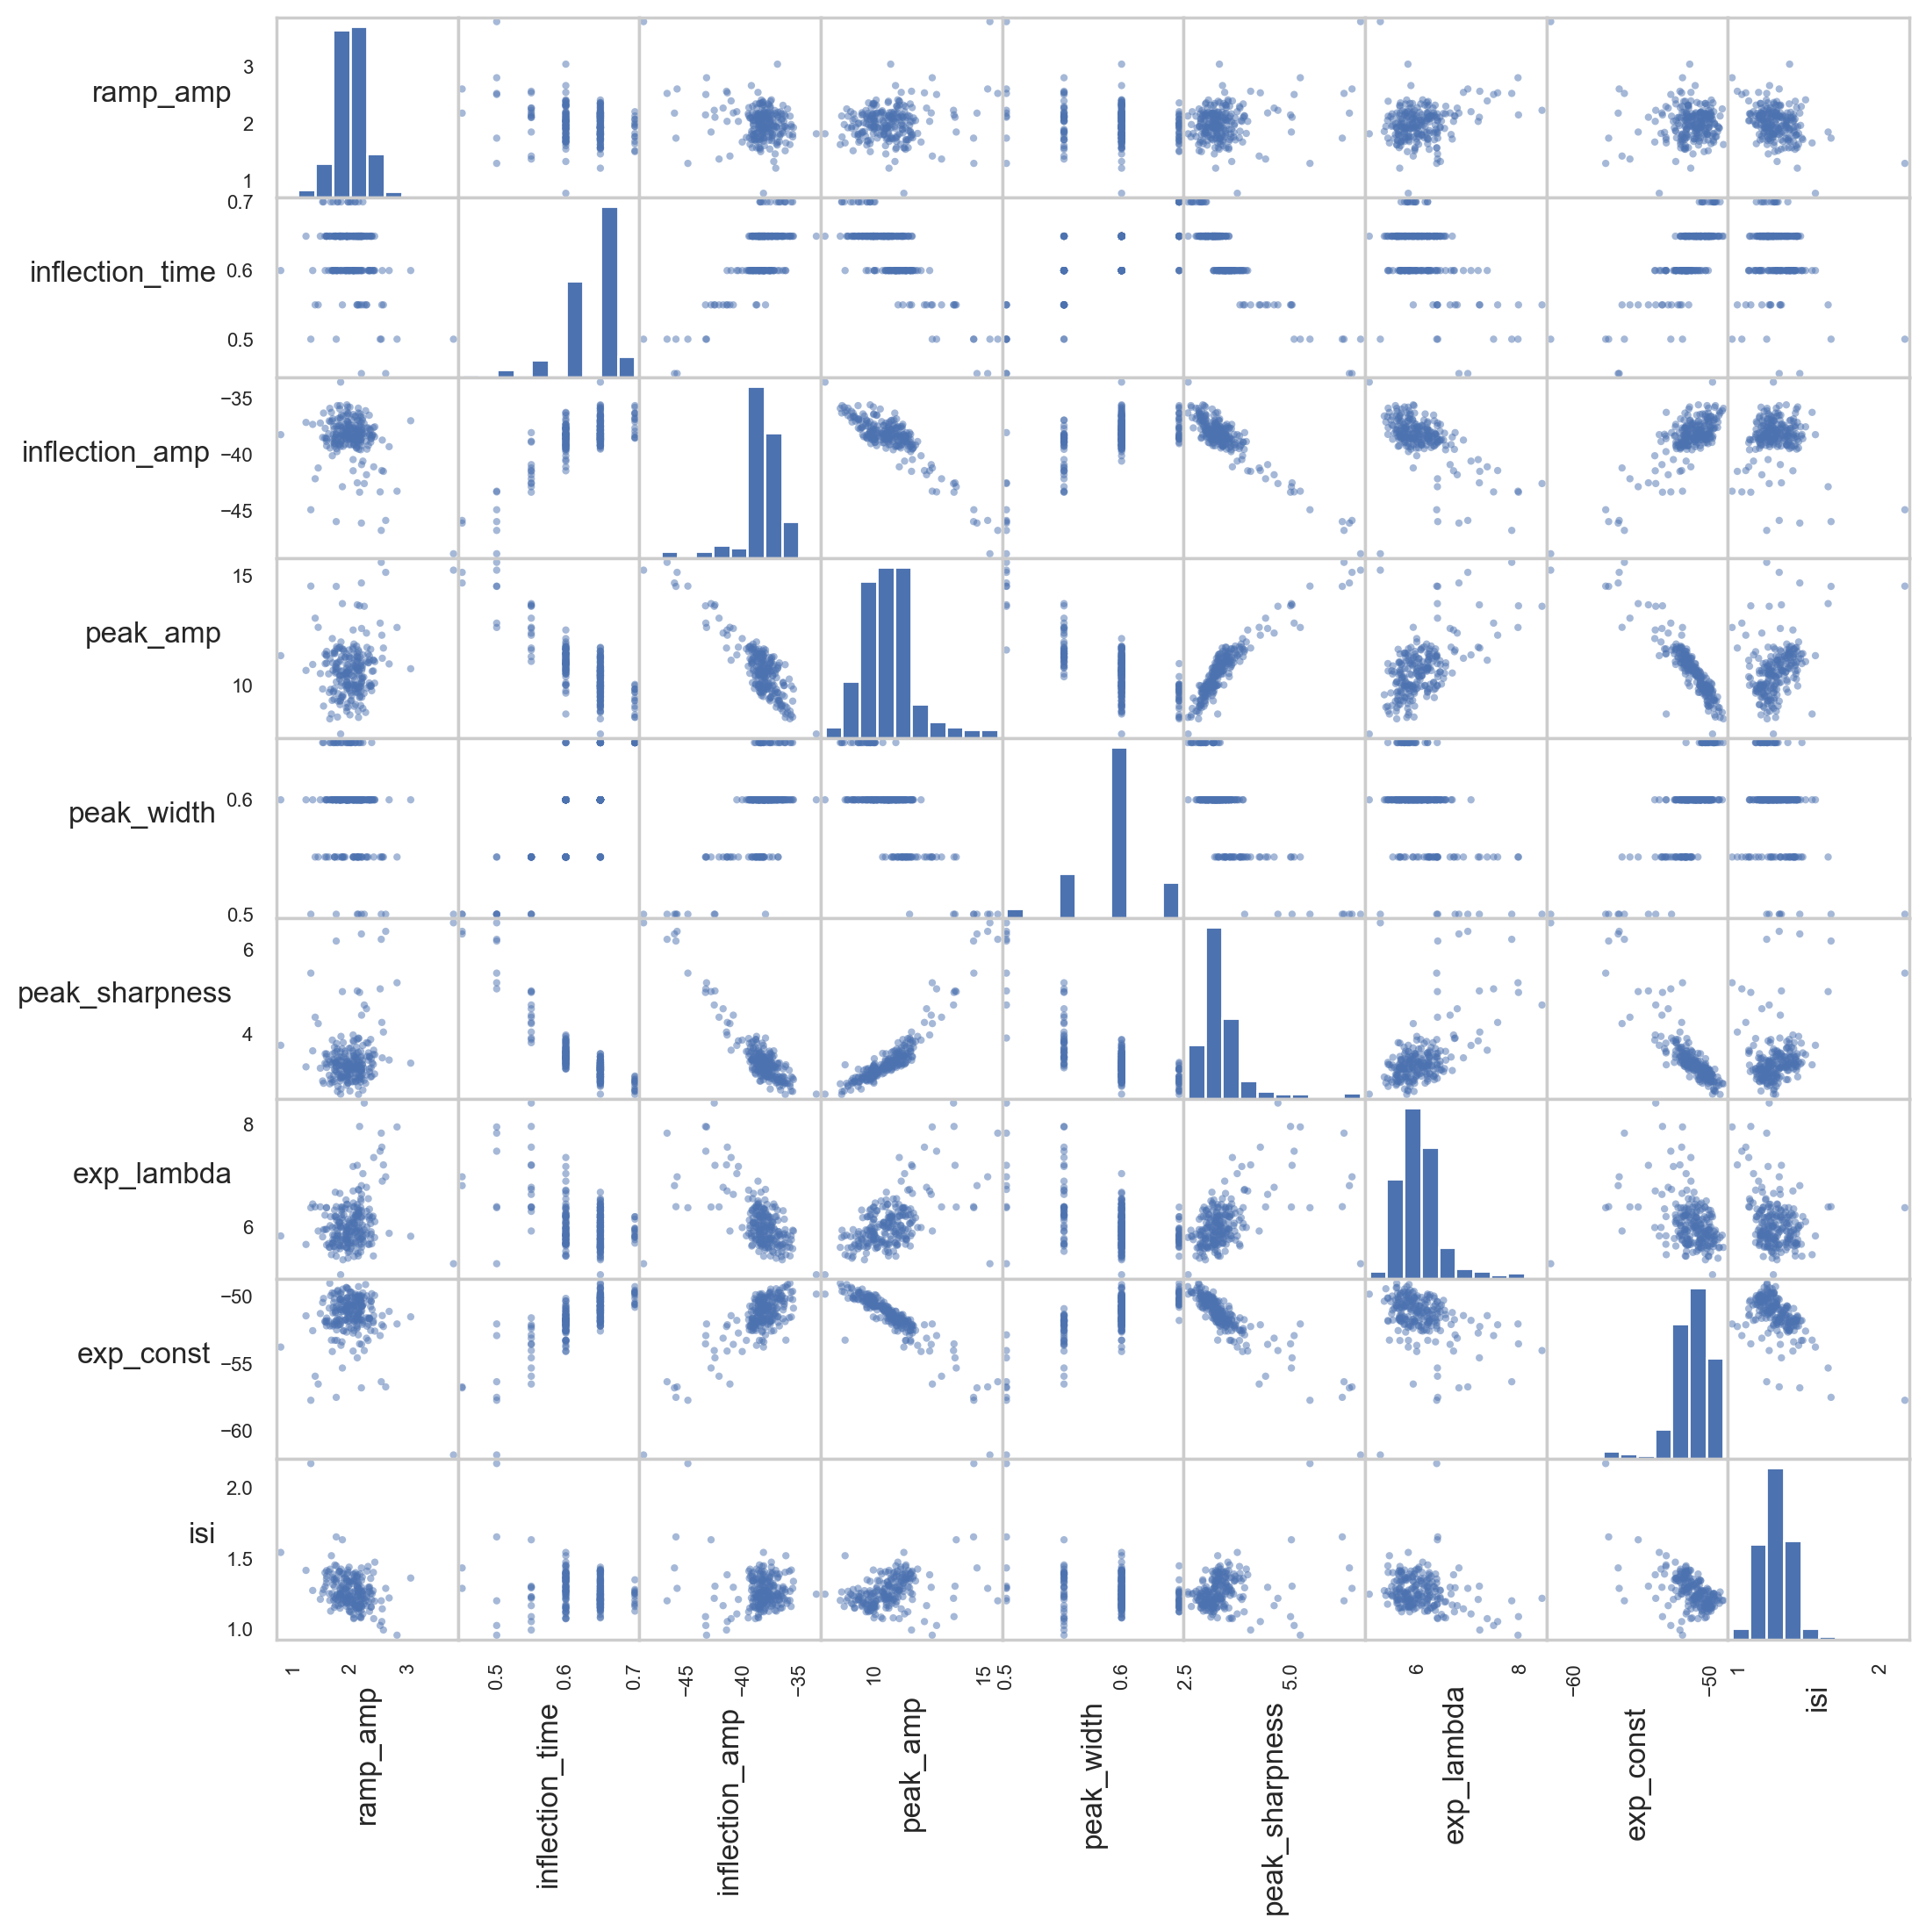

In [14]:
# Ensure inflection times are between 0 and 2 ms
mega_df = mega_df.loc[mega_df['inflection_time'] > 0.]
mega_df = mega_df.loc[mega_df['inflection_time'] < 2.]
# Remove low r-squares (ramping fits are especially noisy)
mega_df = mega_df.loc[mega_df['r_squared_exp']  >= .5]
mega_df = mega_df.loc[mega_df['r_squared_ramp'] >= .1]
# log10 ISIs
mega_df[['isi']] = np.log10(mega_df[['isi']])
# drop no-longer-used QC features
mega_df = mega_df.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
mega_df = mega_df.replace([np.inf, -np.inf], np.nan)

axes = pd.plotting.scatter_matrix(mega_df, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()

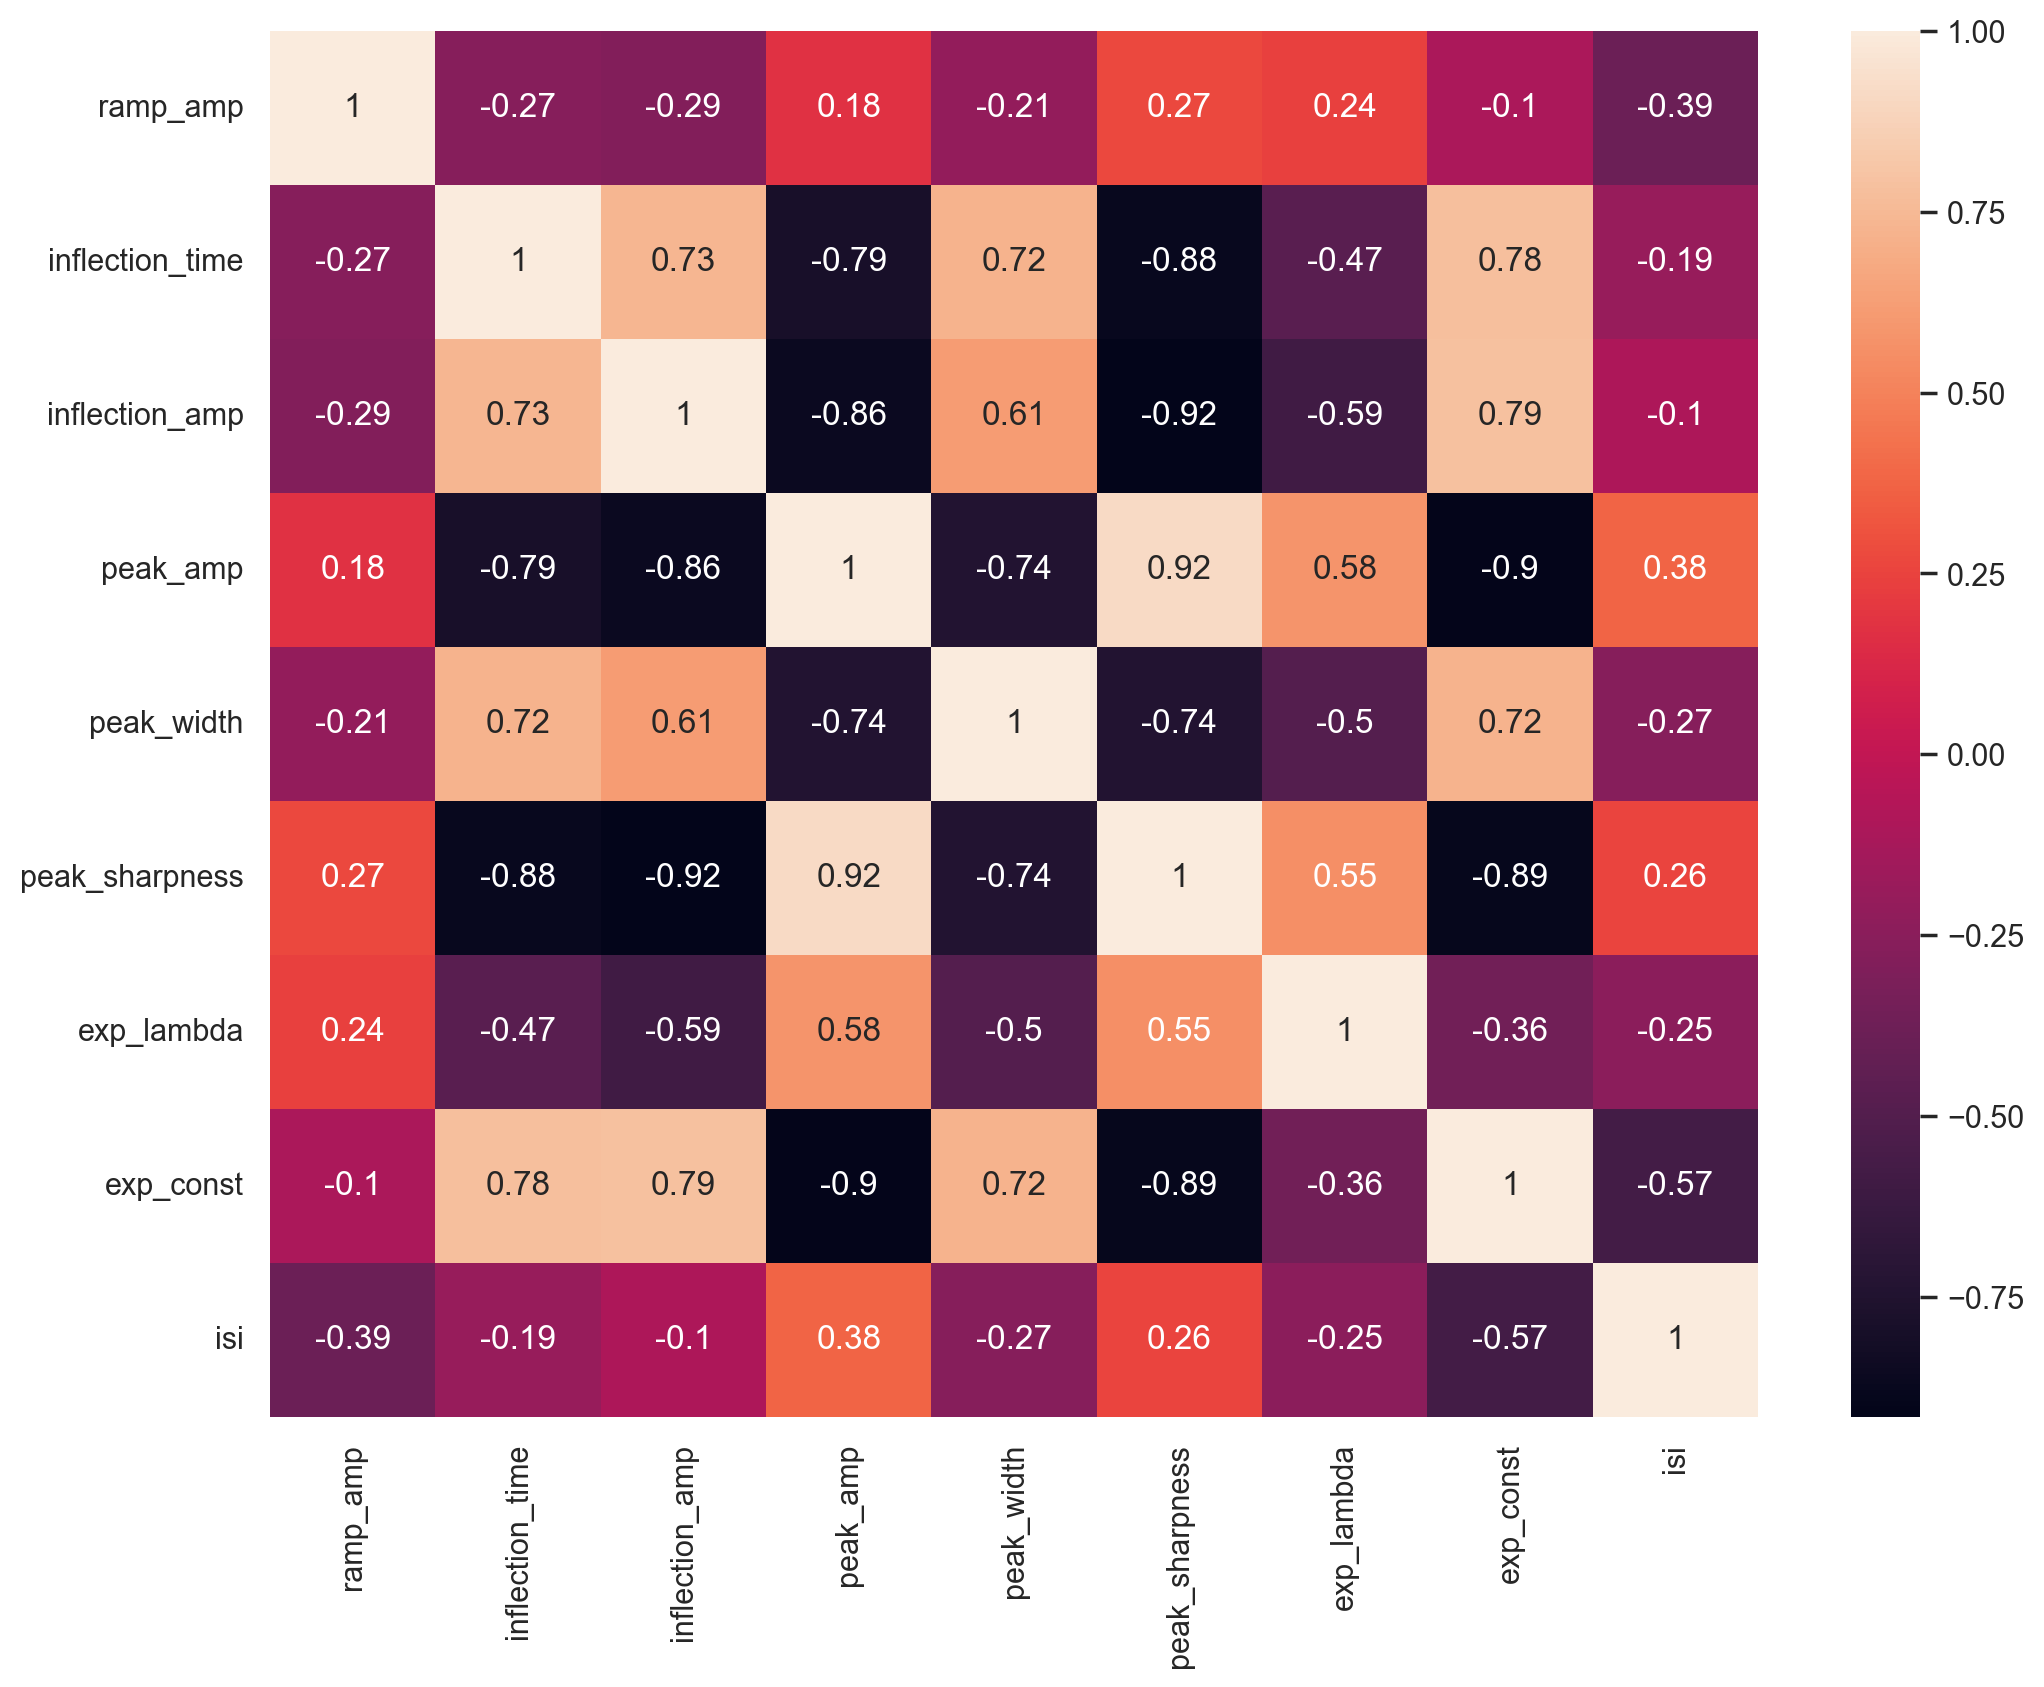

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi
ramp_amp,1.0***,-0.27***,-0.29***,0.18**,-0.21**,0.27***,0.24***,-0.1,-0.39***
inflection_time,-0.27***,1.0***,0.73***,-0.79***,0.72***,-0.88***,-0.47***,0.78***,-0.19**
inflection_amp,-0.29***,0.73***,1.0***,-0.86***,0.61***,-0.92***,-0.59***,0.79***,-0.1
peak_amp,0.18**,-0.79***,-0.86***,1.0***,-0.74***,0.92***,0.58***,-0.9***,0.38***
peak_width,-0.21**,0.72***,0.61***,-0.74***,1.0***,-0.74***,-0.5***,0.72***,-0.27***
peak_sharpness,0.27***,-0.88***,-0.92***,0.92***,-0.74***,1.0***,0.55***,-0.89***,0.26***
exp_lambda,0.24***,-0.47***,-0.59***,0.58***,-0.5***,0.55***,1.0***,-0.36***,-0.25***
exp_const,-0.1,0.78***,0.79***,-0.9***,0.72***,-0.89***,-0.36***,1.0***,-0.57***
isi,-0.39***,-0.19**,-0.1,0.38***,-0.27***,0.26***,-0.25***,-0.57***,1.0***


In [15]:
#take out sweep number for the correlation to work
mega_df_nl = mega_df.drop('Sweep_#', axis=1)
# Plot the heatmap and annotation on it
sns.heatmap(mega_df_nl.corr(), xticklabels=mega_df_nl.corr().columns,
            yticklabels=mega_df_nl.corr().columns, annot=True)
plt.show()
rho = mega_df_nl.corr()
pval = mega_df_nl.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

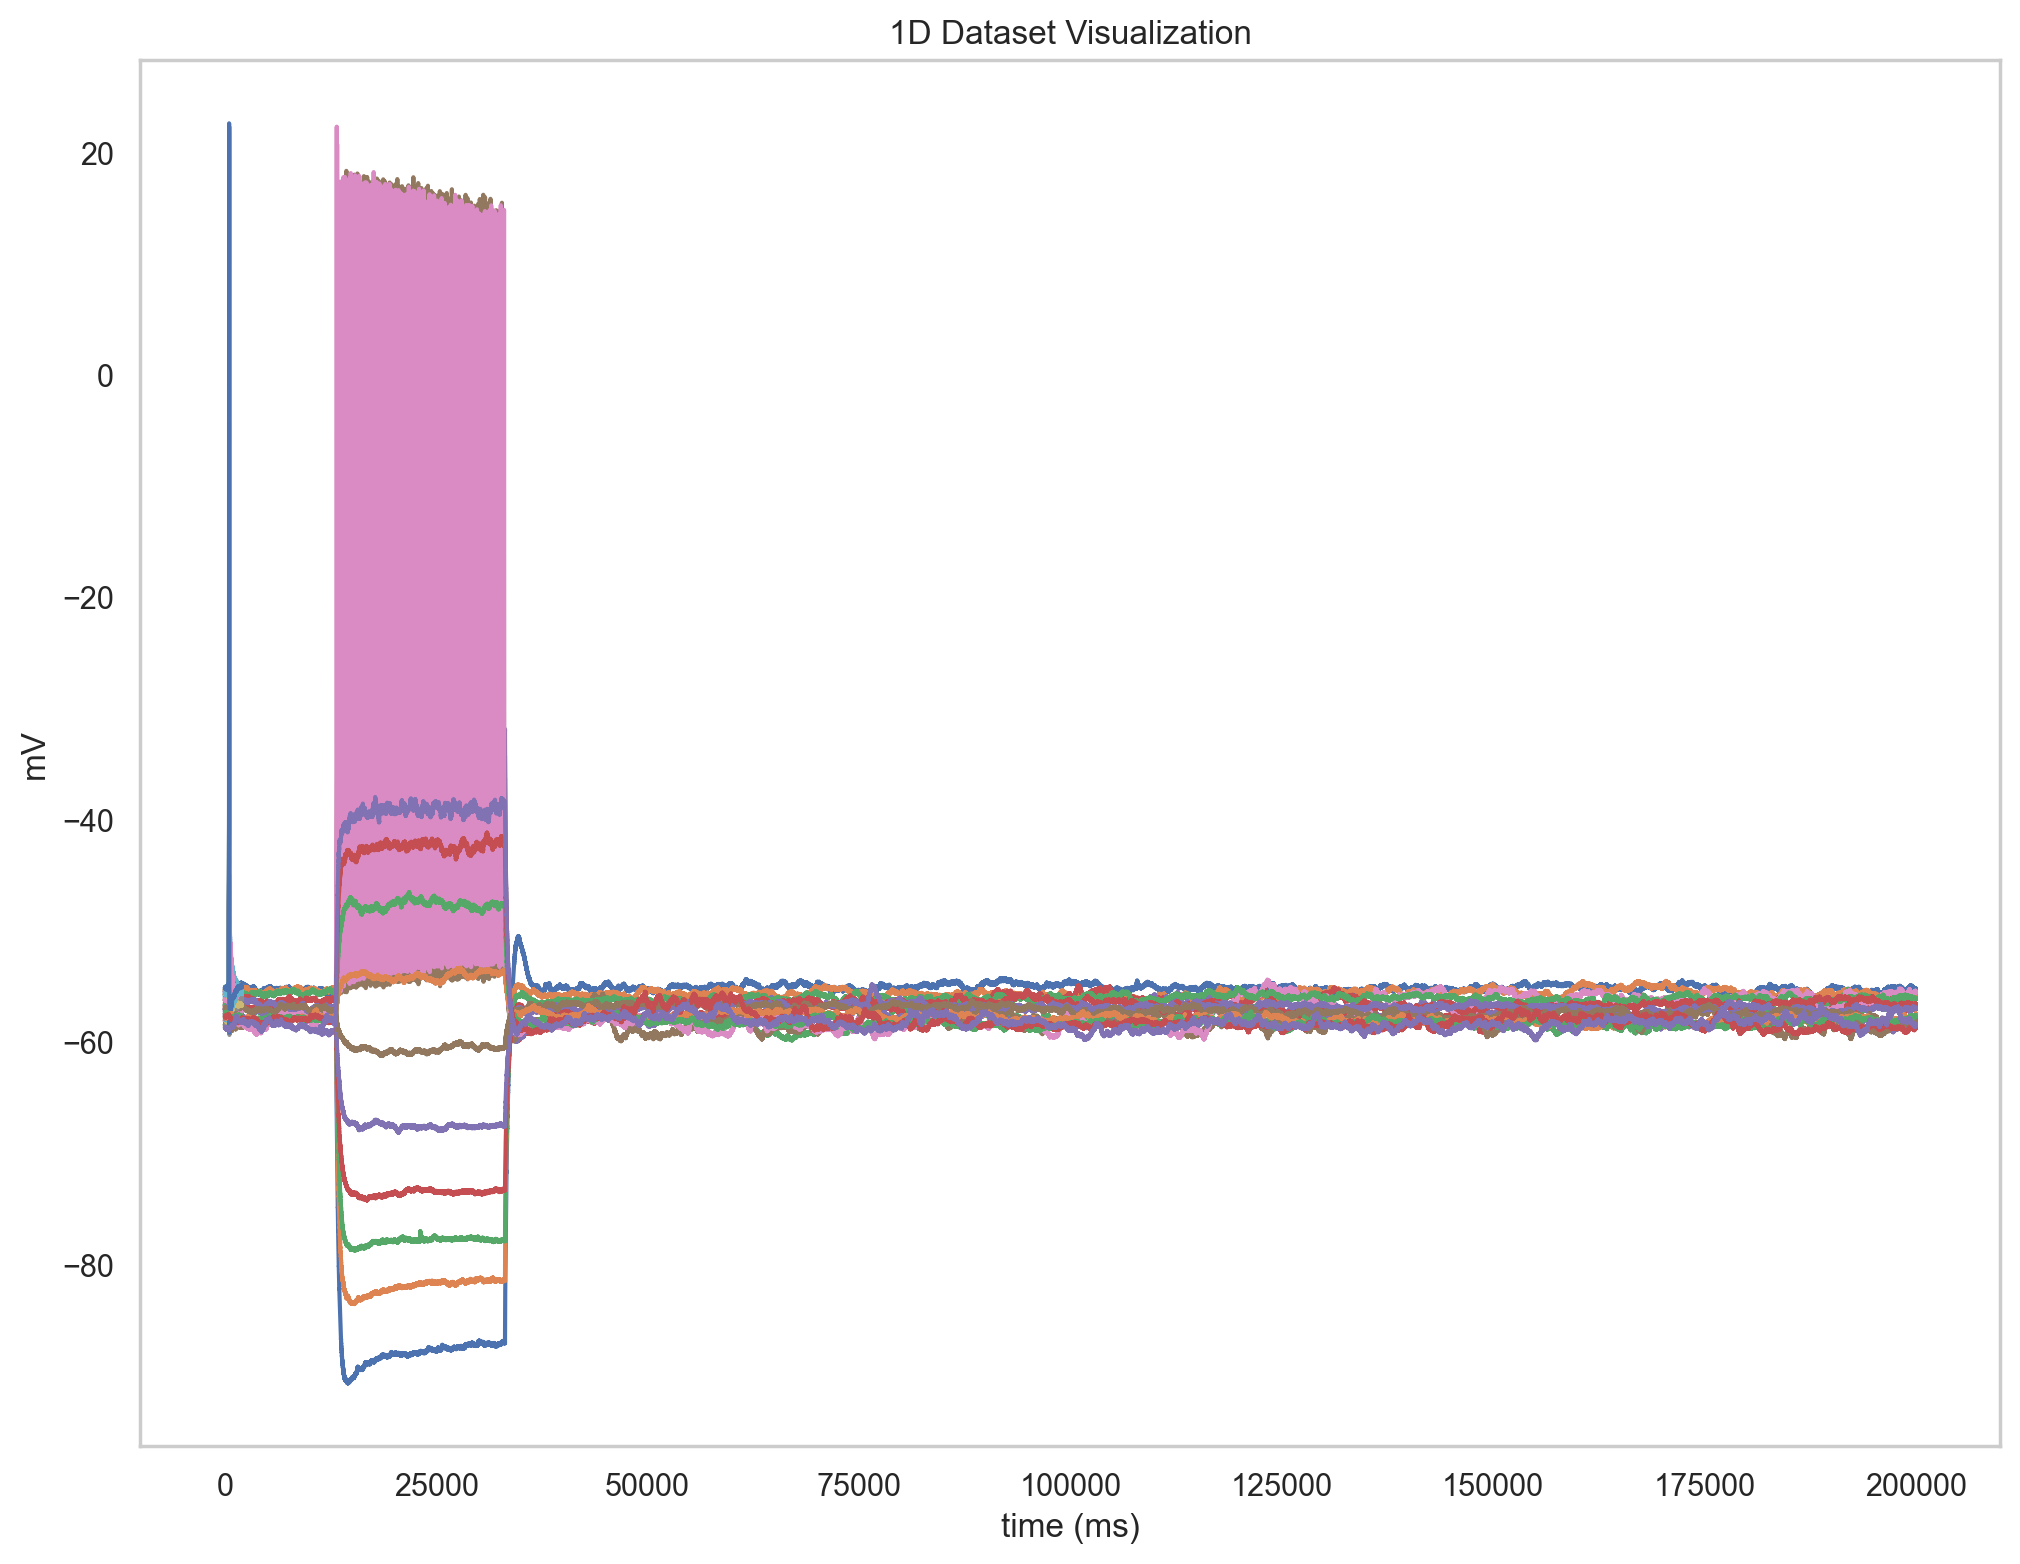

[array([-55.4931653 , -55.45044069, -55.43213015, ..., -55.181886  ,
        -55.21850709, -55.181886  ]),
 array([-55.21240358, -55.20630006, -55.24902467, ..., -55.78613406,
        -55.73730593, -55.76172   ]),
 array([-58.45337045, -58.38623177, -58.45947396, ..., -56.72607549,
        -56.75659307, -56.72607549]),
 array([-56.74438603, -56.80542119, -56.74438603, ..., -57.02514776,
        -57.0007337 , -57.00683721]),
 array([-57.00683721, -56.97021612, -57.05566534, ..., -58.45947396,
        -58.41674935, -58.4350599 ]),
 array([-58.45947396, -58.38623177, -58.36792123, ..., -58.05664192,
        -58.0871595 , -58.06884895]),
 array([-58.00171028, -58.06884895, -58.01391731, ..., -55.50537233,
        -55.48706179, -55.46264772]),
 array([-56.06689578, -56.15234501, -56.10351688, ..., -56.92749151,
        -56.89087041, -56.91528448]),
 array([-56.93359502, -57.01904424, -56.92749151, ..., -56.32324345,
        -56.26220829, -56.29882938]),
 array([-55.90210086, -55.96923953, -

In [17]:
extract_data(r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_SM_A1_C04.nwb")

# Super Mega Dataframe 
adds each file

##### list of NWB files: 

In [18]:
f1 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C01.nwb"
f2 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C03.nwb"
f3 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C04.nwb"
f4 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C06.nwb"
f5 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C10.nwb"
f6 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C14.nwb"
f7 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C19.nwb"
f8 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_MW_A1_C03.nwb"
f9 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_MW_A1_C04.nwb"
f10 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_MW_A1_C06.nwb"
f11 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_MW_A1_C07.nwb"
f12 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_MW_A1_C08.nwb"
f13 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_MW_A1_C09.nwb"
f14 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_MW_A1_C15.nwb"
f15 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_MW_A1_C16.nwb"
f16 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_SM_A1_C02.nwb"
f17 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_SM_A1_C04.nwb"
f18 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_SM_A1_C05.nwb"
f19 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_SM_A1_C07.nwb"
f20 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_SM_A1_C09.nwb"
f21 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_SM_A1_C14.nwb"
f22 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_SM_A1_C15.nwb"
f23 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_SM_A1_C16.nwb"
f24 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C18.nwb"
f25 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C20.nwb"
f26 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_MW_A1_C10.nwb"
f27 = r"C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_MW_A1_C11.nwb"

In [19]:
filepaths = [f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, f11, f12, f13, f14, f15, f16, f17, f18, f19, f20, f21, f22, f23, f24, f25, f26, f27]

### 

In [25]:
# iterate through each file, 
# create a spike object and add the data frame from the object, plus a label from the sweep
# add a label for a file and move to the next file (mega df)
super_mega_df = pd.DataFrame()
for file in filepaths:
    print(file)
    data = extract_data(file, plot_data = False) #numpy array of all sweeps in the file
    spike_dir = {}                               #dictionary of sweeps with spikes
    i = 0
    #threshold in mVs
    with h5py.File(file1, 'r') as f:
        for sweep_key in f['acquisition'].keys():
            print(sweep_key)
            print(i)
            if i < len(data):
                try:
                    sweep_key_obj = Spike(thresh_amp=0, window_length=(5., 5.), smooth_frac=.01)
                    sweep_key_obj.fit(data[i], 20000, n_jobs=-1, progress=tqdm)
                    if sweep_key_obj.n_spikes is not None:
                        spike_dir[sweep_key] = sweep_key_obj
                except ValueError as e:
                    print(f"Fitting failed for sweep {sweep_key}: {e}")
            i += 1
    # creating and concatenating data frame with all sweeps
    mega_df = pd.DataFrame()
    for i in spike_dir:
        print(i)
        df = spike_dir[i].df_features
        df['Sweep_#'] = i
        mega_df = pd.concat([mega_df, df], axis=0)
        mega_df['file_name'] = os.path.splitext(os.path.basename(file))[0] 
    super_mega_df = pd.concat([super_mega_df, mega_df], axis=0)

super_mega_df.head()

C:\Users\david\Documents\Voytek Research\nwb files\primate Dataset\M03_JS_A1_C01.nwb
Sweep_0
0
Sweep_1
1
Sweep_10
2


C:\Users\david\spikeparam\spikeparam\patch\fit\fit.py:228: UserWarning: No spikes detected.
  warnings.warn('No spikes detected.')
Spike: 100%|█████████████████████████████████████████████████████████████████████████████| 9/9 [00:04<00:00,  2.18it/s]


Sweep_11
3


Spike: 100%|███████████████████████████████████████████████████████████████████████████| 42/42 [00:04<00:00,  9.04it/s]


Sweep_12
4


...

Spike: 100%|███████████████████████████████████████████████████████████████████████████| 18/18 [00:06<00:00,  2.69it/s]
C:\Users\david\spikeparam\spikeparam\patch\fit\fit.py:228: UserWarning: No spikes detected.
  warnings.warn('No spikes detected.')


Sweep_30
24
Sweep_31
25
Sweep_32
26
Sweep_33
27
Sweep_34
28
Sweep_35
29


Spike: 100%|█████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.57s/it]
C:\Users\david\spikeparam\spikeparam\patch\fit\fit.py:228: UserWarning: No spikes detected.
  warnings.warn('No spikes detected.')


Sweep_36
30
Sweep_37
31
Sweep_38
32
Sweep_39
33
Sweep_4
34
Sweep_40
35
Sweep_41
36
Sweep_42
37
Sweep_43
38
Sweep_44
39
Sweep_45
40
Sweep_46
41
Sweep_47
42
Sweep_48
43
Sweep_49
44
Sweep_5
45
Sweep_50
46
Sweep_51
47
Sweep_52
48
Sweep_53
49
Sweep_54
50
Sweep_6
51
Sweep_7
52
Sweep_8
53
Sweep_9
54
Sweep_10
Sweep_16
Sweep_18
Sweep_19
Sweep_2
Sweep_20
Sweep_21
Sweep_22
Sweep_23
Sweep_24
Sweep_25
Sweep_26
Sweep_27
Sweep_28
Sweep_29
Sweep_3
Sweep_35


,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp,Sweep_#
0,2.612488,0.45,-45.858766,15.164185,0.50,6.445313,6.970228,-56.733916,19.45,0.996142,0.739826,Sweep_10
1,2.116406,0.55,-42.507936,13.681031,0.50,5.018616,7.193608,-54.574427,20.15,0.998421,0.688264,Sweep_10
2,2.044173,0.60,-41.433717,12.530518,0.55,3.962708,6.693805,-54.071263,24.25,0.984082,0.725384,Sweep_10
3,1.850421,0.60,-38.183595,11.666870,0.55,3.634644,6.344601,-53.386135,24.55,0.994742,0.774003,Sweep_10
4,1.832248,0.60,-38.827516,11.984253,0.55,3.929138,5.981717,-53.646425,26.60,0.950116,0.831859,Sweep_10


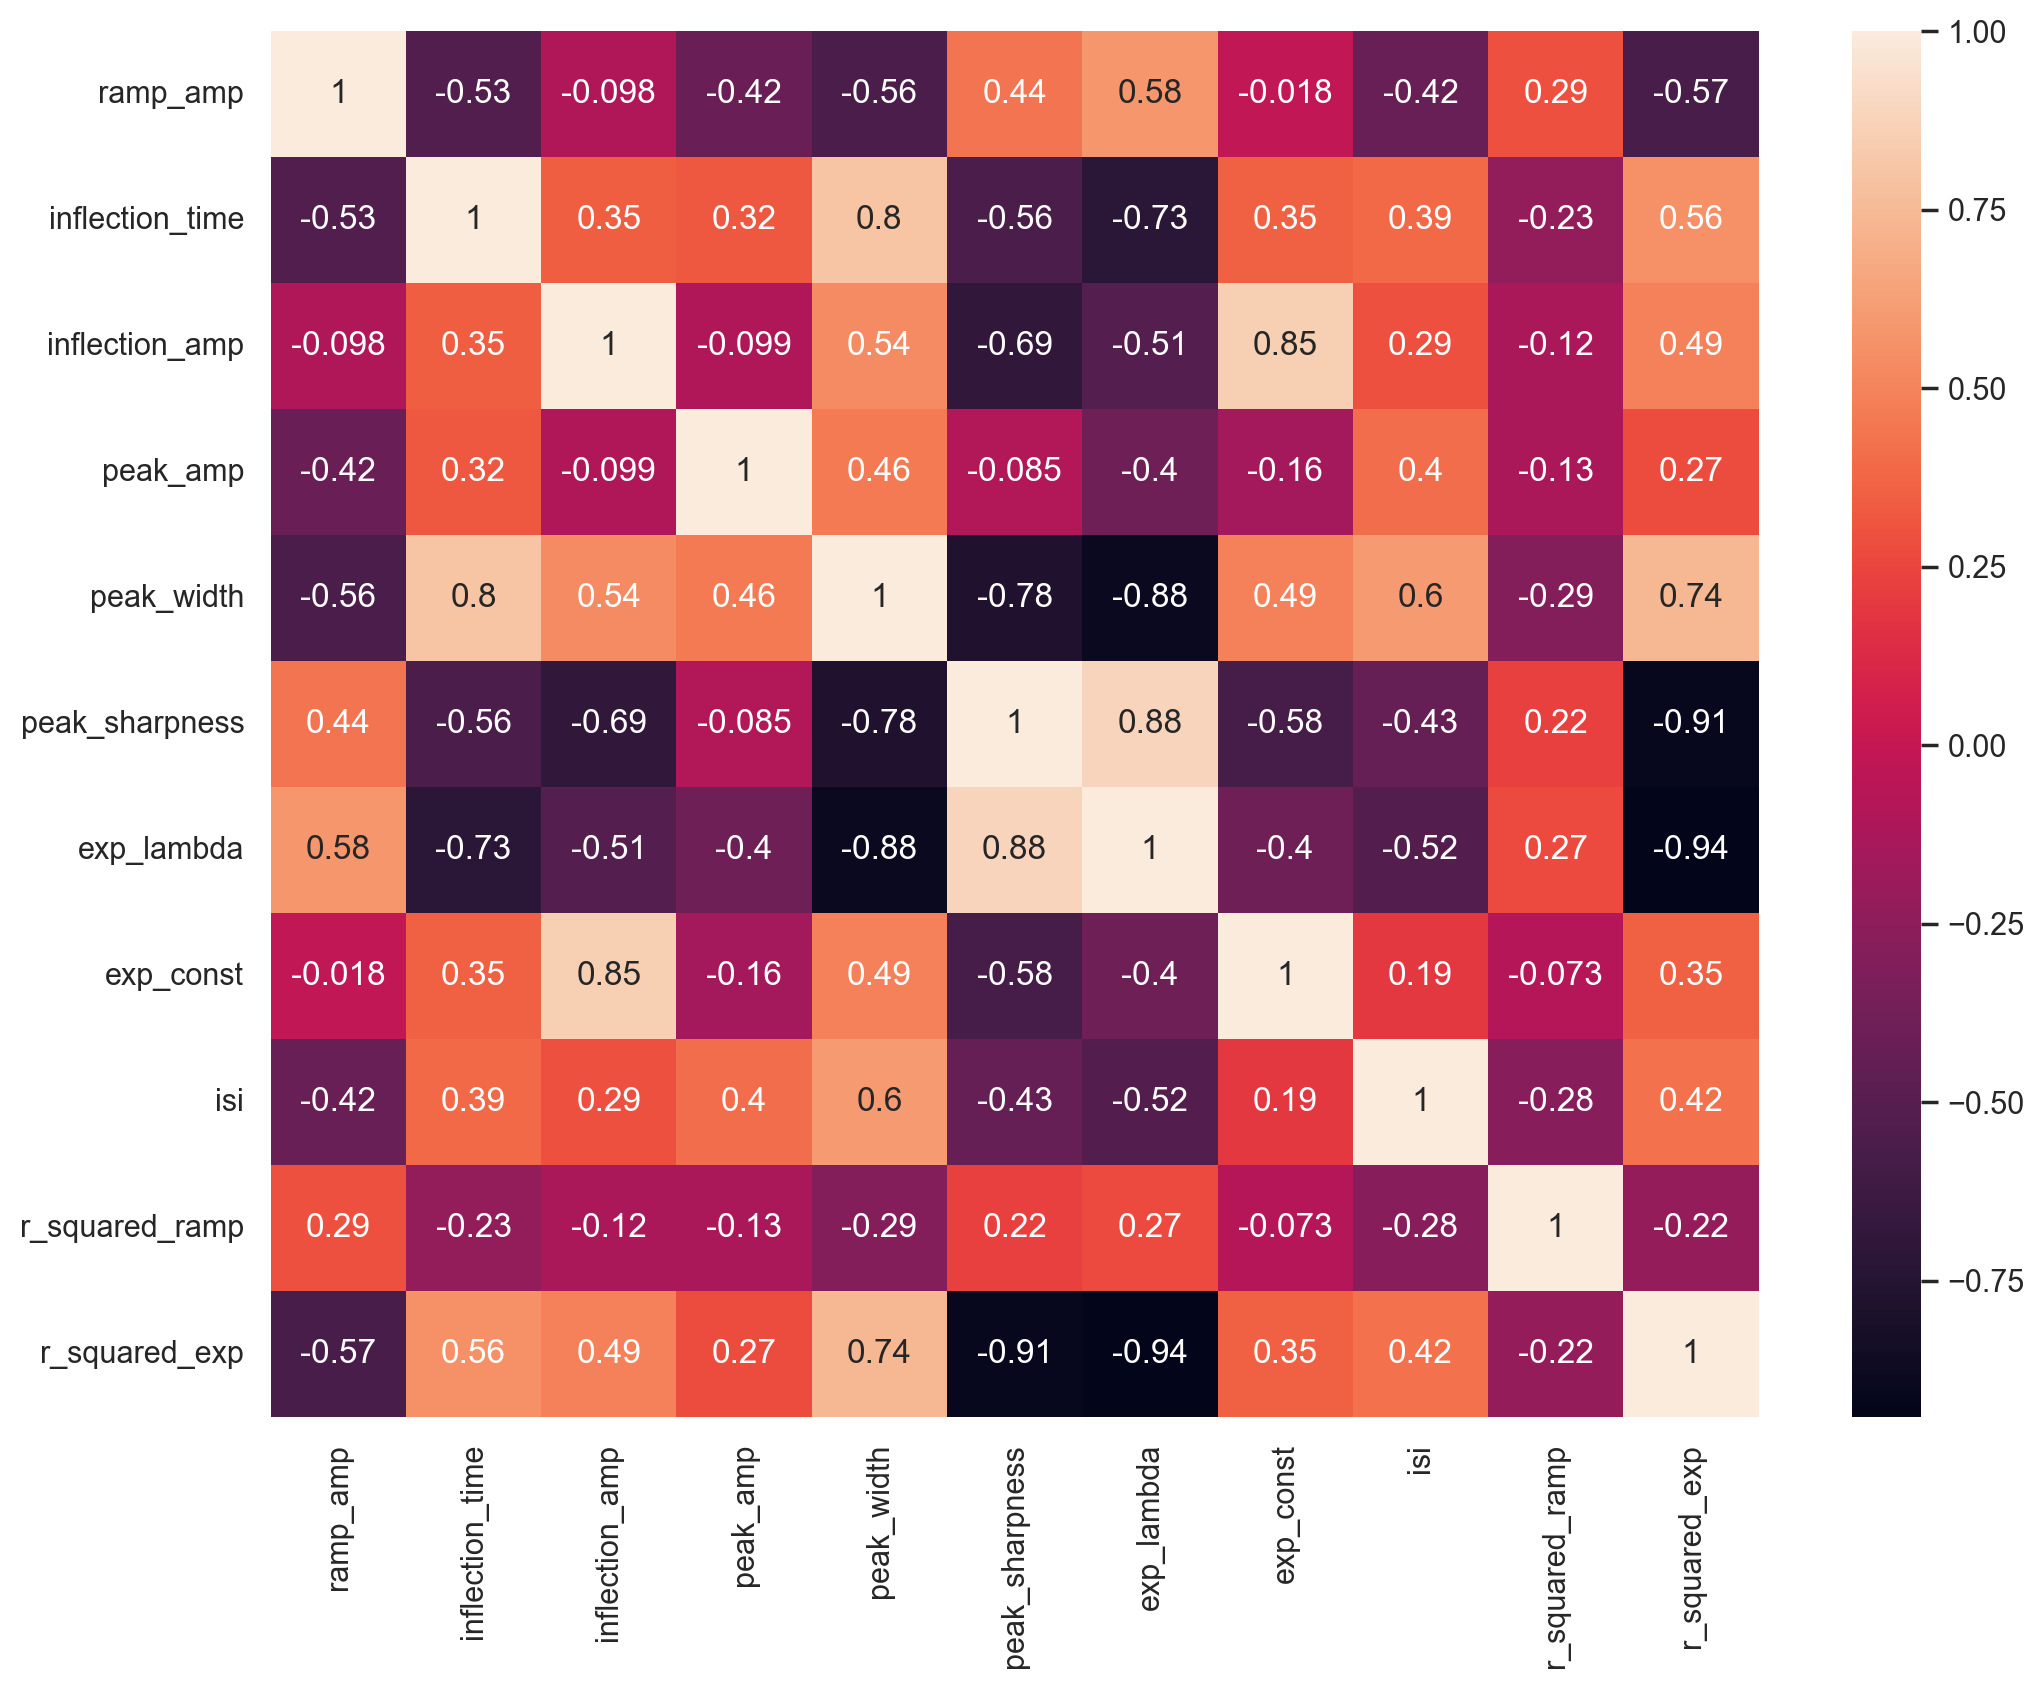

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
ramp_amp,1.0***,-0.53***,-0.1***,-0.42***,-0.56***,0.44***,0.58***,-0.02,-0.42***,0.29***,-0.57***
inflection_time,-0.53***,1.0***,0.35***,0.32***,0.8***,-0.56***,-0.73***,0.35***,0.39***,-0.23***,0.56***
inflection_amp,-0.1***,0.35***,1.0***,-0.1***,0.54***,-0.69***,-0.51***,0.85***,0.29***,-0.12***,0.49***
peak_amp,-0.42***,0.32***,-0.1***,1.0***,0.46***,-0.09***,-0.4***,-0.16***,0.4***,-0.13***,0.27***
peak_width,-0.56***,0.8***,0.54***,0.46***,1.0***,-0.78***,-0.88***,0.49***,0.6***,-0.29***,0.74***
peak_sharpness,0.44***,-0.56***,-0.69***,-0.09***,-0.78***,1.0***,0.88***,-0.58***,-0.43***,0.22***,-0.91***
exp_lambda,0.58***,-0.73***,-0.51***,-0.4***,-0.88***,0.88***,1.0***,-0.4***,-0.52***,0.27***,-0.94***
exp_const,-0.02,0.35***,0.85***,-0.16***,0.49***,-0.58***,-0.4***,1.0***,0.19***,-0.07***,0.35***
isi,-0.42***,0.39***,0.29***,0.4***,0.6***,-0.43***,-0.52***,0.19***,1.0***,-0.28***,0.42***
r_squared_ramp,0.29***,-0.23***,-0.12***,-0.13***,-0.29***,0.22***,0.27***,-0.07***,-0.28***,1.0***,-0.22***


In [26]:
#take out sweep number for the correlation to work
super_mega_df_nl = super_mega_df.drop('Sweep_#', axis=1)
# Plot the heatmap and annotation on it
sns.heatmap(super_mega_df_nl.corr(), xticklabels=super_mega_df_nl.corr().columns,
            yticklabels=super_mega_df_nl.corr().columns, annot=True)
plt.show()
rho = super_mega_df_nl.corr()
pval = super_mega_df_nl.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

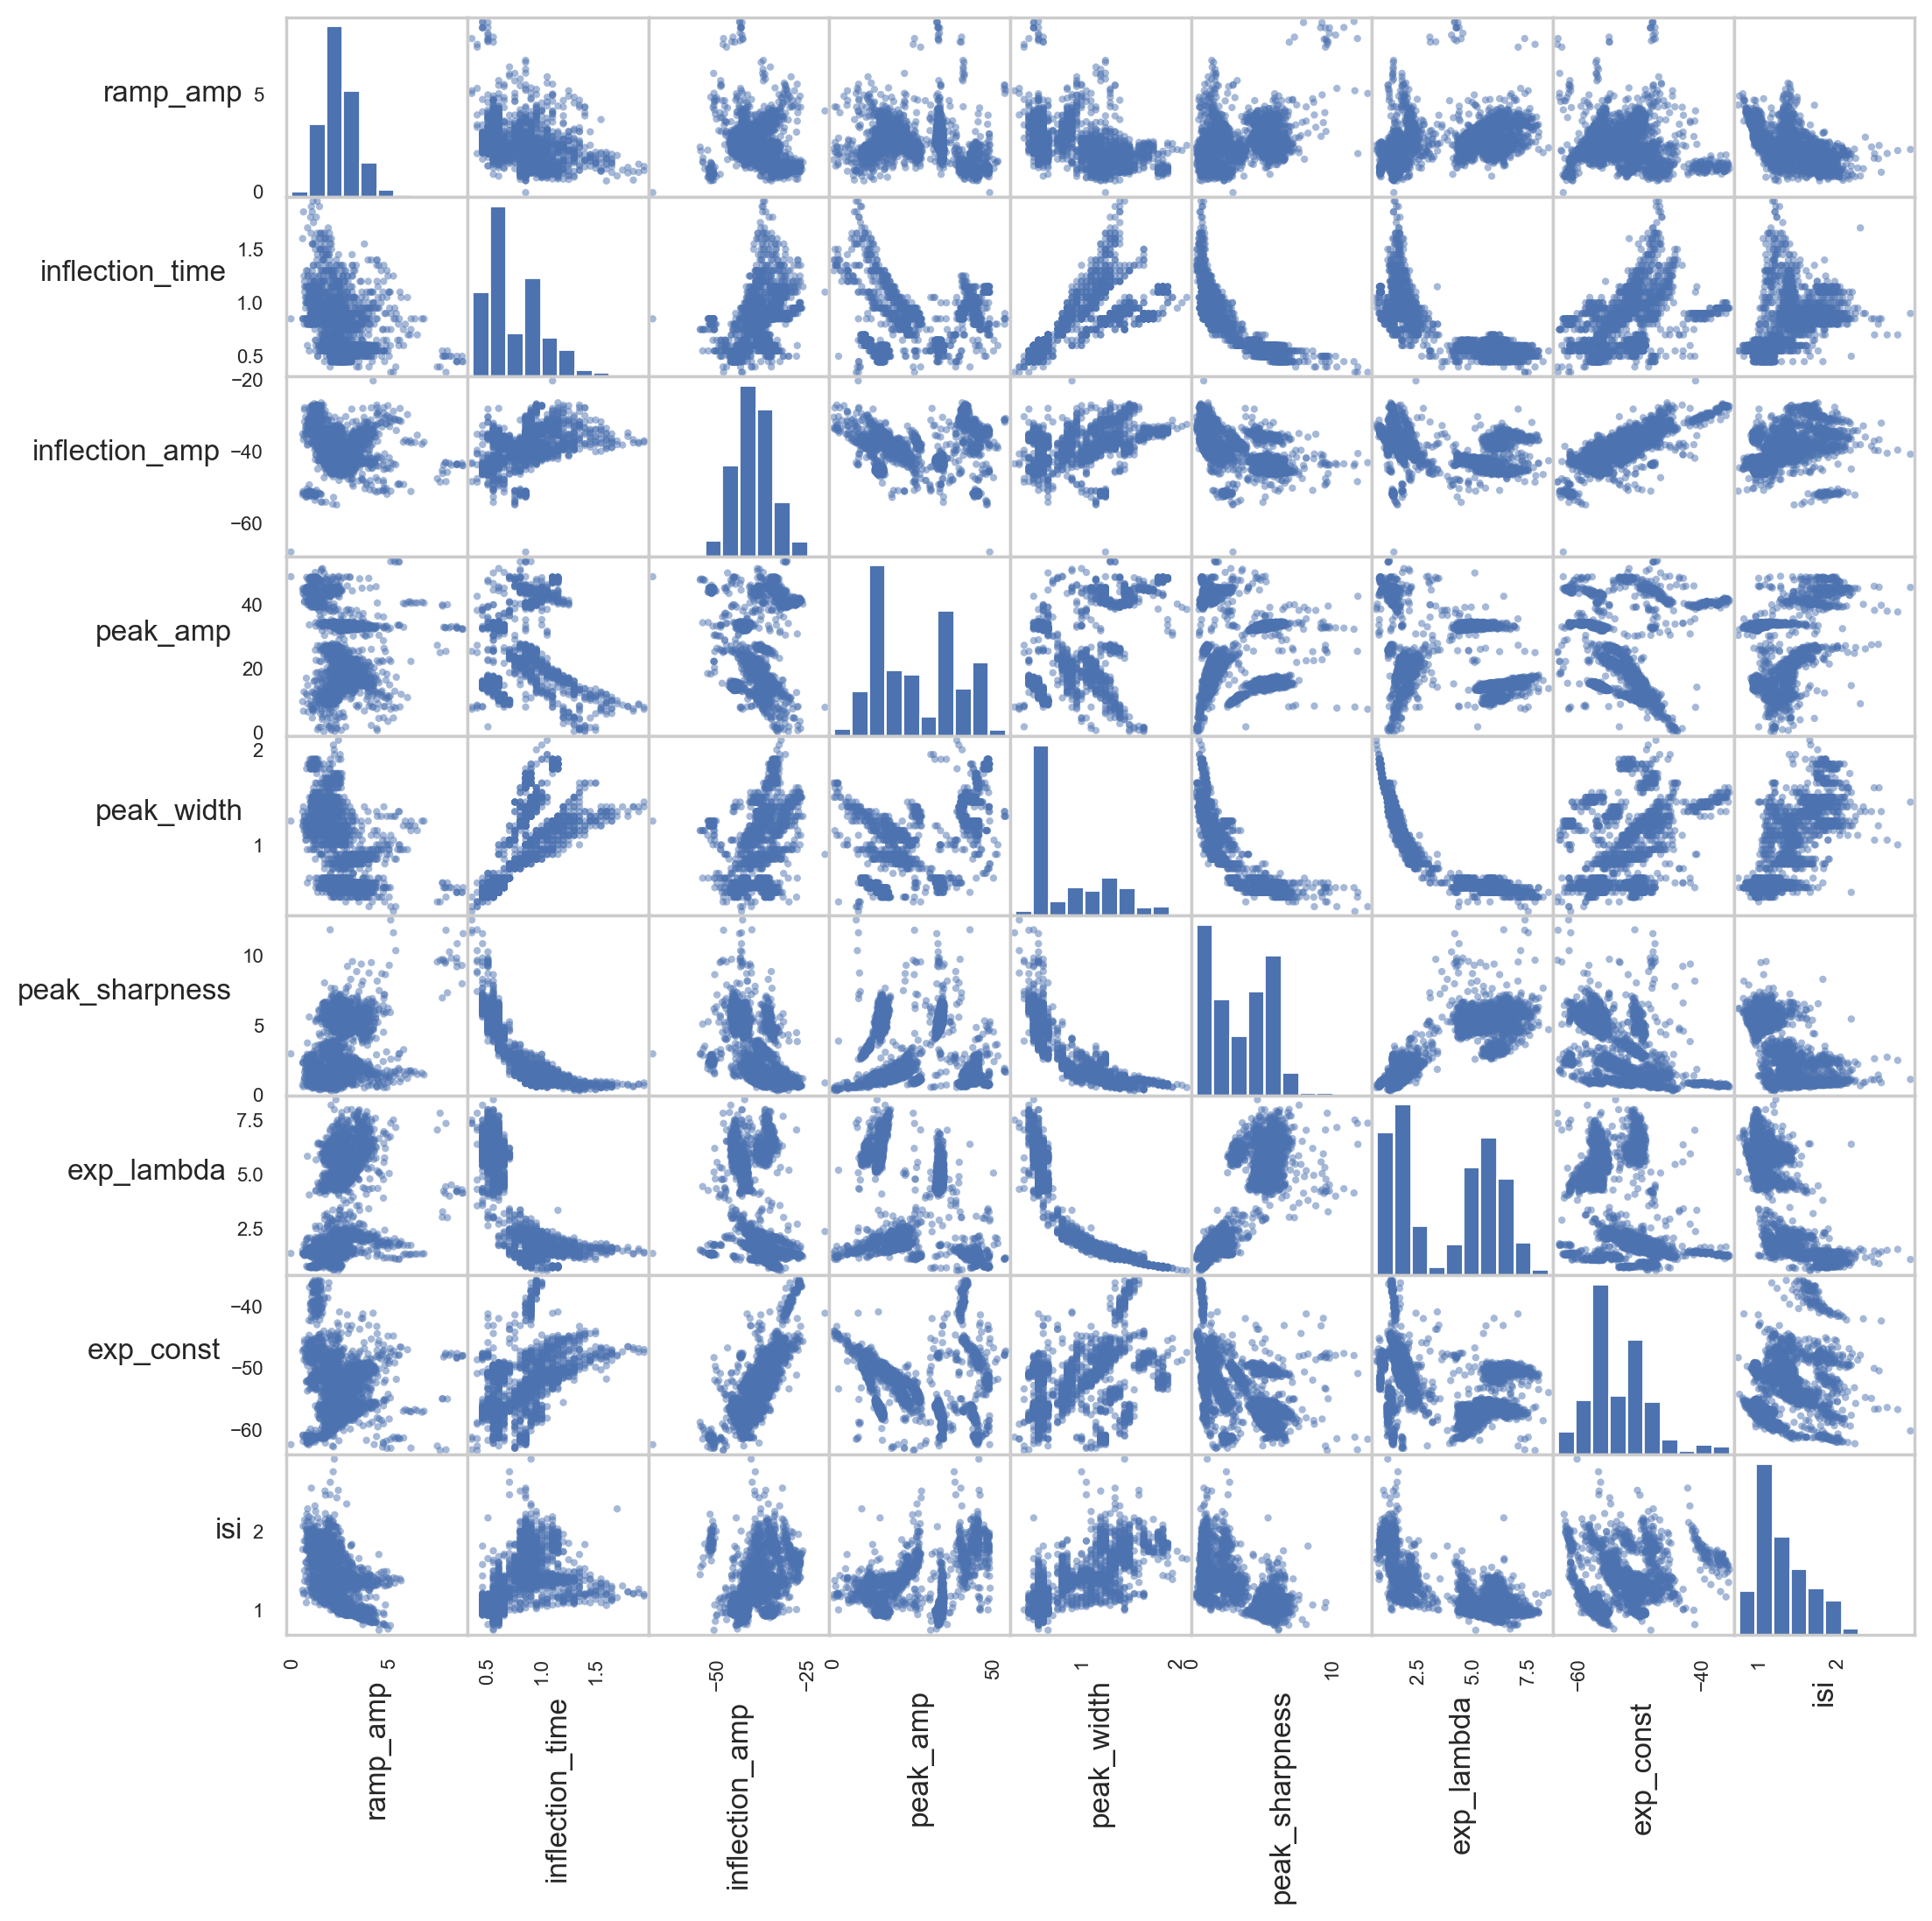

In [28]:
# Ensure inflection times are between 0 and 2 ms
super_mega_df = super_mega_df.loc[super_mega_df['inflection_time'] > 0.]
super_mega_df = super_mega_df.loc[super_mega_df['inflection_time'] < 2.]
# Remove low r-squares (ramping fits are especially noisy)
super_mega_df = super_mega_df.loc[super_mega_df['r_squared_exp']  >= .5]
super_mega_df = super_mega_df.loc[super_mega_df['r_squared_ramp'] >= .1]
# log10 ISIs
super_mega_df[['isi']] = np.log10(super_mega_df[['isi']])
# drop no-longer-used QC features
super_mega_df = super_mega_df.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
super_mega_df = super_mega_df.replace([np.inf, -np.inf], np.nan)

axes = pd.plotting.scatter_matrix(super_mega_df, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()